# Adult Income Prediction
## Binary Classification of Individuals Earning More Than \$50K per Year

| | |
| --- | --- |
| **Student** | Ali Hussain Yousif |
| **Topic** | Income Prediction (Binary Classification) |
| **Cohort** | DSB PT3 |
| **Deliverable** | Data Science Capstone — Final Technical Report |

**Data source:** Adult (Census Income) dataset, originally published by the UCI Machine Learning Repository from the 1994 US Census. The CSV file used in this project was obtained from Kaggle.

**Data format:** CSV (`adult.csv`) containing 32,561 rows and 15 columns before cleaning.

## Introduction

This project uses the Adult (Census Income) dataset from the 1994 US Census, containing 32,561 records and 14 demographic and employment attributes per person. Each record describes one individual, and the target variable records whether that person's annual income exceeded $50,000.

## Problem Statement and Aim

Identifying likely high-income individuals from demographic and employment information is a common requirement in financial services, where organisations need to direct limited outreach towards the prospects most likely to qualify for premium products.

**Aim:** Build and compare classification models that predict whether an individual earns more than $50,000 per year, and identify which factors most strongly influence that outcome.

In this setting the two types of error are not equally costly. A false positive means contacting someone who does not qualify, which wastes one outreach effort. A false negative means failing to identify a qualified prospect, which forfeits the entire opportunity. Missing a high earner is therefore more costly than contacting the wrong person, and our evaluation reflects this.

## Objectives

1. Investigate and correct data quality issues, documenting the reasoning behind each cleaning decision.
2. Explore the relationships between demographic, educational, and employment factors and income level.
3. Select features using correlation analysis for numerical variables and chi-square tests for categorical variables.
4. Build and tune six classification models: Logistic Regression (baseline), Decision Tree, Random Forest, Support Vector Machine, XGBoost, and K-Nearest Neighbours.
5. Compare the models using metrics appropriate to an imbalanced target and recommend the best one with justification.
6. Identify the features that most influence the prediction and discuss their practical implications.

# 1. Data Inspection

## 1.1 Data Dictionary
| Column         | Type        | Description                  |
| -------------- | ----------- | ---------------------------- |
| age            | Numerical   | Age of individual            |
| workclass      | Categorical | Type of employment           |
| fnlwgt         | Numerical   | Census sampling weight; excluded from the final model |
| education      | Categorical | Education level; excluded because it duplicates the information in education.num |
| education.num  | Numerical   | Education level encoded      |
| marital.status | Categorical | Marital status               |
| occupation     | Categorical | Job type                     |
| relationship   | Categorical | Household relationship       |
| race           | Categorical | Race category                |
| sex            | Categorical | Gender                       |
| capital.gain   | Numerical   | Capital gains                |
| capital.loss   | Numerical   | Capital losses               |
| hours.per.week | Numerical   | Weekly working hours         |
| native.country | Categorical | Country of origin            |
| income         | Categorical | Income class (>50K or <=50K) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

In [2]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
# Check the column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [4]:
# Summary statistics for the numerical columns
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 1.2 Checking for Missing Values

`df.info()` reports that every column is complete. We confirm this with an explicit null check, and then verify the result by inspecting the actual categories stored in each text column.

In [5]:
# Standard missing value check
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [6]:
# The null check reports nothing missing, so we inspect the actual values
# stored in each categorical column to confirm this is true
categorical_cols = ['workclass', 'education', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country', 'income']

for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print()

workclass
<ArrowStringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

education
<ArrowStringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

marital.status
<ArrowStringArray>
[              'Widowed',              'Divorced',             'Separated',
         'Never-married',    'Married-civ-spouse', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str

occupation
<ArrowStringArray>
[                '?',   'Exec-managerial', 'Machine-op-inspct',
    'Prof-specialty',     'Other-service',      'Adm-clerical',
      'Craft-repair',  'Transport-moving', 'Handlers-cleane

In [7]:
# Count how many '?' values exist in each categorical column
for col in categorical_cols:
    count = (df[col] == '?').sum()
    print(col, count)

workclass 1836
education 0
marital.status 0
occupation 1843
relationship 0
race 0
sex 0
native.country 583
income 0


In [8]:
# Check for exact duplicate rows
df.duplicated().sum()

np.int64(24)

### Findings

- `df.isnull().sum()` reports zero missing values, but this is misleading. Missing values in this dataset are stored as the string `'?'`, which Pandas reads as a normal category.
- Three columns contain `'?'`: `workclass` (1,836 rows, 5.64%), `occupation` (1,843 rows, 5.66%), and `native.country` (583 rows, 1.79%).
- 2,399 rows (7.37% of the dataset) contain at least one `'?'`.
- The dataset also contains 24 exact duplicate rows.
- `education` and `education.num` appear to carry the same information in two formats, which we will confirm during feature selection.

These issues are recorded here and handled in the Data Cleaning section, so that each cleaning decision is made deliberately rather than automatically.

## 1.3 Handling Missing Values

The `'?'` values are concentrated in `workclass`, `occupation`, and `native.country`. `workclass` and `occupation` are missing together in 1,836 of the same rows, so they represent one underlying situation rather than two separate problems.

Comparing these rows against the rest of the dataset shows they are not a random sample:

| | Missing `workclass` | Other rows |
|---|---|---|
| Mean age | 41.0 | 38.4 |
| % over age 65 | 16.7% | 2.8% |
| Mean hours per week | 31.9 | 41.0 |
| % earning >50K | 10.4% | 24.9% |

These records mainly describe people who are outside the labour force, and they earn above $50K at less than half the rate of the rest of the dataset. The fact that a value is missing therefore carries information about income.

**Decision: replace the missing values with an explicit `Unknown` category.**

We rejected the two common alternatives:

- **Dropping the rows** would remove 7.37% of the data and specifically remove the retired and part-time group, leaving the model unable to handle such people at prediction time.
- **Mode imputation** would be actively misleading. The most frequent occupation is `Prof-specialty`, in which 44.9% earn above $50K, while the missing group is only 10.4%. Filling with the mode would assign 1,843 low-income records to a high-income occupation.

Treating the missing values as `Unknown` keeps every row, invents no values, and preserves a pattern that is genuinely predictive.

In [9]:
# The '?' values are missing data stored as text.
# Convert them to NaN so that Pandas recognises them as missing.
df = df.replace('?', np.nan)

# Confirm the missing values are now detected correctly
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [10]:
# Replace the missing values with an explicit 'Unknown' category,
# because the missing rows describe a real group (people outside the labour force)
# and we do not want to guess a value for them.
df['workclass'] = df['workclass'].fillna('Unknown')
df['occupation'] = df['occupation'].fillna('Unknown')
df['native.country'] = df['native.country'].fillna('Unknown')

# Confirm no missing values remain
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [11]:
# Check that 'Unknown' now appears as a normal category
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Unknown              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

## 1.4 Duplicate Rows

The dataset contains 24 exact duplicate rows. Before removing them we checked whether they are likely to be recording errors or simply different people with the same recorded values.

Ignoring `fnlwgt` (a survey weight rather than a personal attribute), **3,465 rows** are identical to another row on all 14 descriptive columns. With only 14 mostly categorical features, two different people sharing the same profile is common rather than unusual. All 47 rows involved in the exact duplicates also have `capital.gain` and `capital.loss` equal to zero, which are the two columns that most often distinguish records.

We therefore cannot conclude that these rows are errors.

**Decision: remove the 24 exact duplicates.**

The reasoning is practical rather than certain. They represent 0.07% of the data, so removing them costs almost nothing, while keeping them leaves a small risk that the same record appears in both the training and test sets and inflates the test score. We remove only *exact* duplicates and keep the 3,465 partial matches, since those are distinct survey records with different sampling weights.

The 3,465 figure is itself a useful finding: when identical feature rows carry different income labels, no model can classify both correctly. This places an upper limit on the accuracy achievable with this feature set, and we return to it in the Limitations section.

In [12]:
# Count exact duplicate rows
df.duplicated().sum()

np.int64(24)

In [13]:
# Check how many rows are identical if we ignore fnlwgt,
# since fnlwgt is a survey weight and not a personal characteristic
columns_without_weight = df.columns.drop('fnlwgt')

df.duplicated(subset=columns_without_weight).sum()

np.int64(3465)

In [14]:
# Remove the 24 exact duplicate rows
df = df.drop_duplicates()

# Confirm the new shape and that no exact duplicates remain
print(df.shape)
print(df.duplicated().sum())

(32537, 15)
0


## 1.5 Target Variable and Evaluation Strategy

The target variable `income` has two classes.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count of each income class
print(df['income'].value_counts())

# Percentage of each income class
print(df['income'].value_counts(normalize=True) * 100)

income
<=50K    24698
>50K      7839
Name: count, dtype: int64
income
<=50K    75.907428
>50K     24.092572
Name: proportion, dtype: float64


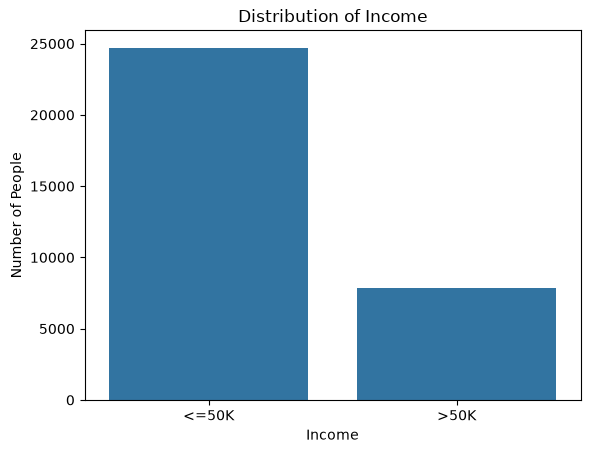

In [16]:
# Visualise the balance of the target variable
sns.countplot(data=df, x='income')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Number of People')
plt.show()

### Class Imbalance and Metric Selection

The target is imbalanced: 75.91% of individuals earn `<=50K` and 24.09% earn `>50K`, a ratio of roughly 3.15 to 1.

This has a direct consequence for evaluation. A model that predicts `<=50K` for every person would achieve **75.91% accuracy** while identifying no high earners at all. Accuracy alone is therefore misleading here, because it is dominated by the majority class and leaves only a narrow range in which meaningful differences between models can appear.

**Decision: we use ROC-AUC as the primary metric for model selection and hyperparameter tuning, and report Accuracy, Precision, Recall, F1-score, and the confusion matrix for every model.**

ROC-AUC measures how well a model ranks individuals by their likelihood of earning above $50K, independently of any particular decision threshold. This separates two questions that should not be confused: whether the model has learned a useful ordering, and where the decision cutoff should be placed. Tuning on ROC-AUC optimises the first, which cannot be corrected later. The threshold is adjusted separately after the final model is selected.

The imbalance is moderate rather than severe, so we do not apply resampling techniques at this stage. The approach to class imbalance is addressed in the modelling section.

Note that `income` is kept as text for the exploratory analysis so that charts remain readable. It is converted to a numeric target (0 and 1) in the preprocessing section.

# 2. Exploratory Data Analysis

The purpose of this section is to identify which features carry information about income, and to check whether any features duplicate each other. Each chart answers a specific question rather than describing the data for its own sake.

Because the target is imbalanced, we compare groups using the **percentage earning above $50K** within each group rather than raw counts. A raw count chart would mostly show which categories are large, not which are associated with higher income.

## 2.1 Categorical Features and Income

In [17]:
# Create a numeric version of the target so we can calculate the percentage
# of high earners within each group. This same column becomes our target later.
df['high_income'] = (df['income'] == '>50K').astype(int)

df['high_income'].mean() * 100

np.float64(24.092571533945968)

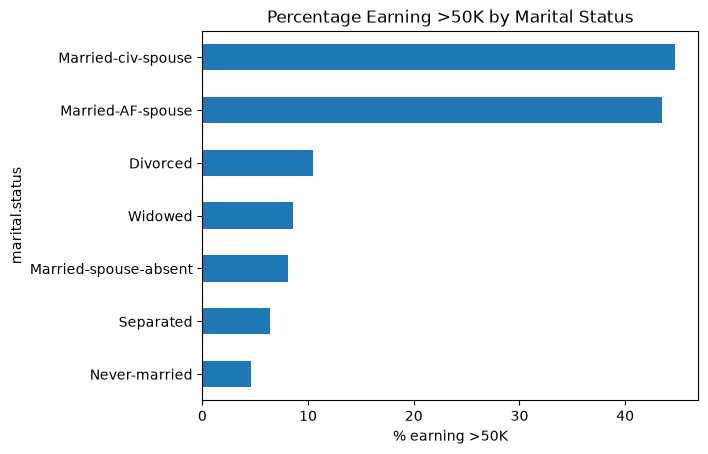

marital.status
Never-married             4.6
Separated                 6.4
Married-spouse-absent     8.1
Widowed                   8.6
Divorced                 10.4
Married-AF-spouse        43.5
Married-civ-spouse       44.7
Name: high_income, dtype: float64


In [18]:
# Question: does marital status relate to income?
marital_rate = df.groupby('marital.status')['high_income'].mean() * 100

marital_rate.sort_values().plot(kind='barh')
plt.title('Percentage Earning >50K by Marital Status')
plt.xlabel('% earning >50K')
plt.show()

print(marital_rate.sort_values().round(1))

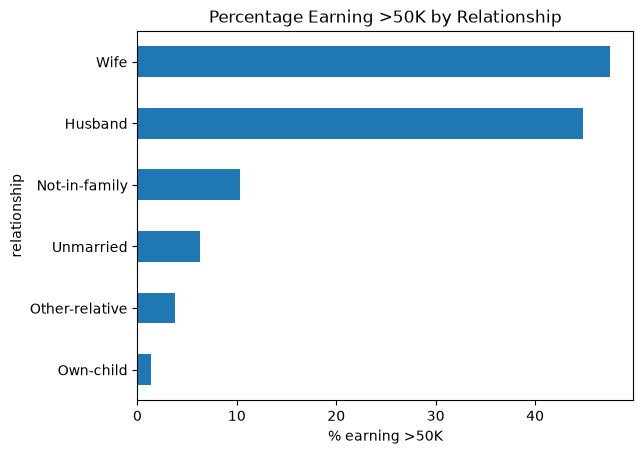

relationship
Own-child          1.3
Other-relative     3.8
Unmarried          6.3
Not-in-family     10.3
Husband           44.9
Wife              47.5
Name: high_income, dtype: float64


In [19]:
# Question: does relationship status add anything beyond marital status?
relationship_rate = df.groupby('relationship')['high_income'].mean() * 100

relationship_rate.sort_values().plot(kind='barh')
plt.title('Percentage Earning >50K by Relationship')
plt.xlabel('% earning >50K')
plt.show()

print(relationship_rate.sort_values().round(1))

In [20]:
# Check how much the two columns overlap
pd.crosstab(df['marital.status'], df['relationship'])

relationship,Husband,Not-in-family,Other-relative,Own-child,Unmarried,Wife
marital.status,,,,,,
Divorced,0,2403,110,328,1600,0
Married-AF-spouse,9,0,1,1,0,12
Married-civ-spouse,13178,17,124,95,0,1556
Married-spouse-absent,0,211,32,45,130,0
Never-married,0,4694,611,4481,881,0
Separated,0,420,55,99,451,0
Widowed,0,547,48,15,383,0


In [21]:
# Within the 'Never-married' group only, does relationship separate income further?
never_married = df[df['marital.status'] == 'Never-married']

print(never_married.groupby('relationship')['high_income'].agg(['size', 'mean']).round(3))

                size   mean
relationship               
Not-in-family   4694  0.091
Other-relative   611  0.013
Own-child       4481  0.008
Unmarried        881  0.026


In [22]:
# Married people are older, so check whether the marital status effect
# is really just an age effect
print(df.groupby('marital.status')['age'].mean().round(1))

marital.status
Divorced                 43.0
Married-AF-spouse        32.5
Married-civ-spouse       43.2
Married-spouse-absent    40.6
Never-married            28.2
Separated                39.4
Widowed                  59.0
Name: age, dtype: float64


In [23]:
# Compare marital status groups within a fixed age band
age_band = df[(df['age'] >= 35) & (df['age'] <= 50)]

print(age_band.groupby('marital.status')['high_income'].mean().sort_values().round(3) * 100)

marital.status
Separated                 7.6
Widowed                   9.5
Married-spouse-absent    11.3
Divorced                 11.3
Never-married            13.2
Married-AF-spouse        50.0
Married-civ-spouse       52.5
Name: high_income, dtype: float64


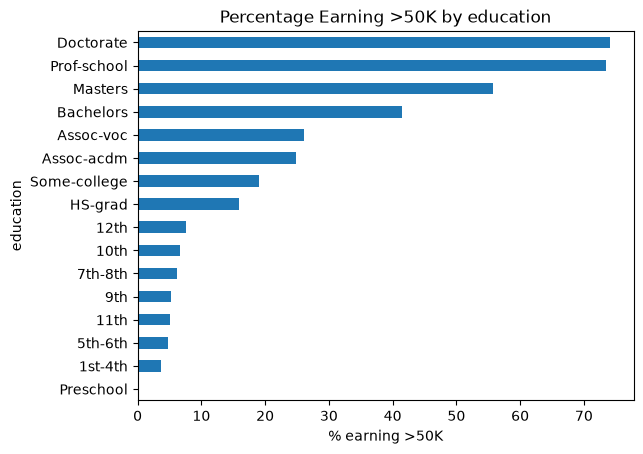

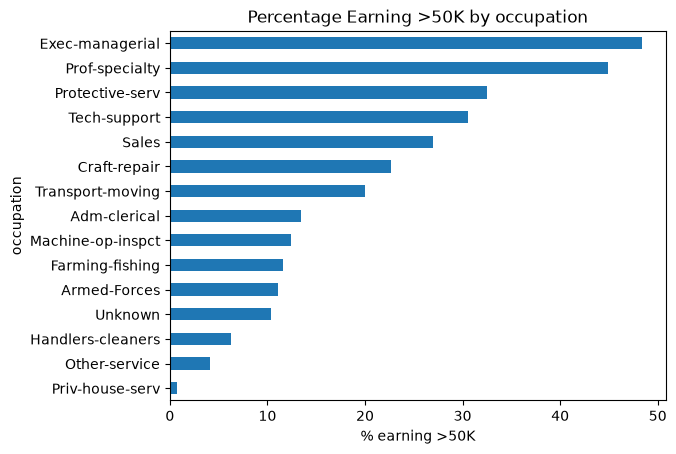

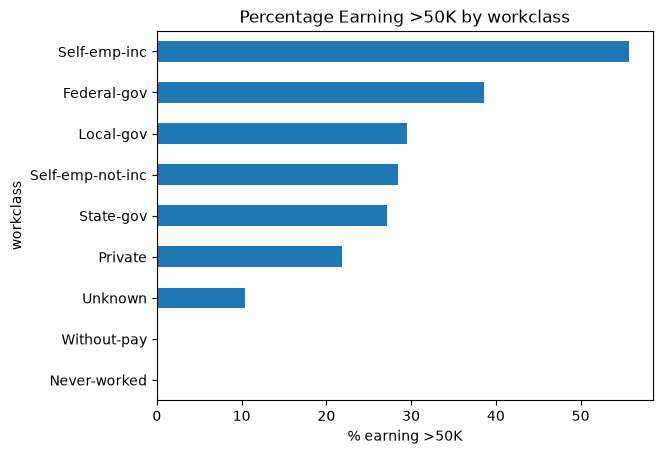

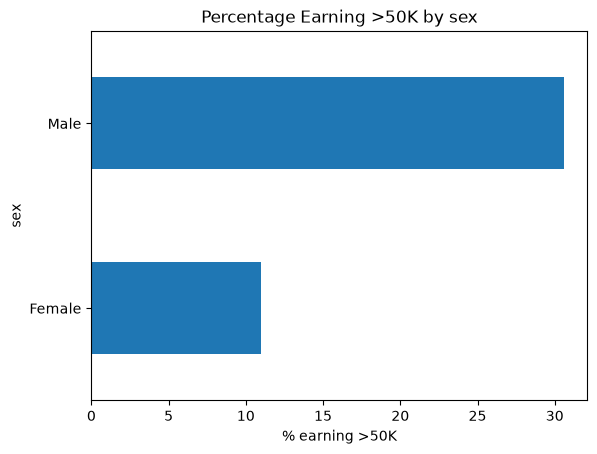

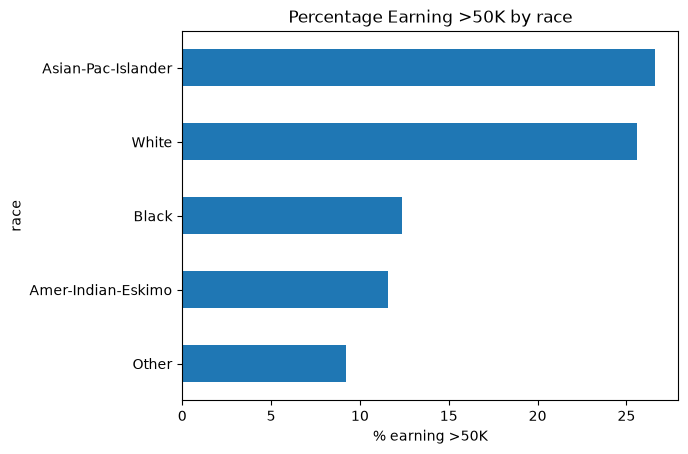

In [24]:
# Question: which other categorical features separate income groups?
for col in ['education', 'occupation', 'workclass', 'sex', 'race']:
    rate = df.groupby(col)['high_income'].mean() * 100
    rate.sort_values().plot(kind='barh')
    plt.title('Percentage Earning >50K by ' + col)
    plt.xlabel('% earning >50K')
    plt.show()

### Insights: Categorical Features

- **Marital status is the strongest categorical signal.** 44.7% of married individuals (`Married-civ-spouse`) earn above $50K, compared with 4.6% of those who never married — almost a tenfold difference.
- **This is not simply an age effect.** Married individuals are older on average (43.2 vs 28.2 years), so we compared groups within the 35–50 age band. The gap remained large (52.5% vs 13.2%), indicating that marital status carries information beyond age.
- **`relationship` and `marital.status` overlap but are not interchangeable.** All 14,755 `Husband`/`Wife` records are married, so `relationship` adds little on the married side. However, it splits the 10,667 `Never-married` individuals into meaningfully different groups: `Own-child` (0.8% high earners, mean age 23.5, still living in a parental household) versus `Not-in-family` (9.1%). `marital.status` treats these as one group. Conversely, `marital.status` separates divorced, widowed and separated individuals, which `relationship` merges. **We therefore retain both features.**
- **Occupation separates income strongly**, ranging from 0.7% (`Priv-house-serv`) to 48.4% (`Exec-managerial`). The `Unknown` category created during cleaning sits at 10.4%, confirming it behaves as a distinct low-income group rather than as noise.
- **Education shows a clear upward trend**, with professional and doctoral qualifications far above high-school completion.
- **Employment sector matters:** 55.7% of the self-employed-incorporated group earn above $50K, versus 21.9% in the private sector.
- **Sex shows a large gap** (30.6% of men versus 11.0% of women), reflecting the labour market of 1994.
- **`race` and `native.country` show weaker associations** and are assessed formally in the feature selection section rather than removed on visual inspection alone.

**A note on interpretation.** The `relationship` categories `Husband` and `Wife` are almost perfectly determined by sex (13,186 of 13,187 `Husband` records are male). Any importance the model later assigns to these categories therefore partly reflects gender. This is noted again in the discussion of limitations.

## 2.2 Numerical Features

We examine the distribution of each numerical feature, check for outliers, and assess how each relates to income.

In [25]:
numerical_cols = ['age', 'fnlwgt', 'education.num',
                  'capital.gain', 'capital.loss', 'hours.per.week']

print(df[numerical_cols].describe().round(2))

            age      fnlwgt  education.num  capital.gain  capital.loss  \
count  32537.00    32537.00       32537.00      32537.00      32537.00   
mean      38.59   189780.85          10.08       1078.44         87.37   
std       13.64   105556.47           2.57       7387.96        403.10   
min       17.00    12285.00           1.00          0.00          0.00   
25%       28.00   117827.00           9.00          0.00          0.00   
50%       37.00   178356.00          10.00          0.00          0.00   
75%       48.00   236993.00          12.00          0.00          0.00   
max       90.00  1484705.00          16.00      99999.00       4356.00   

       hours.per.week  
count        32537.00  
mean            40.44  
std             12.35  
min              1.00  
25%             40.00  
50%             40.00  
75%             45.00  
max             99.00  


In [26]:
# Skewness tells us which features have very unbalanced distributions
print(df[numerical_cols].skew().round(2))

age                0.56
fnlwgt             1.45
education.num     -0.31
capital.gain      11.95
capital.loss       4.59
hours.per.week     0.23
dtype: float64


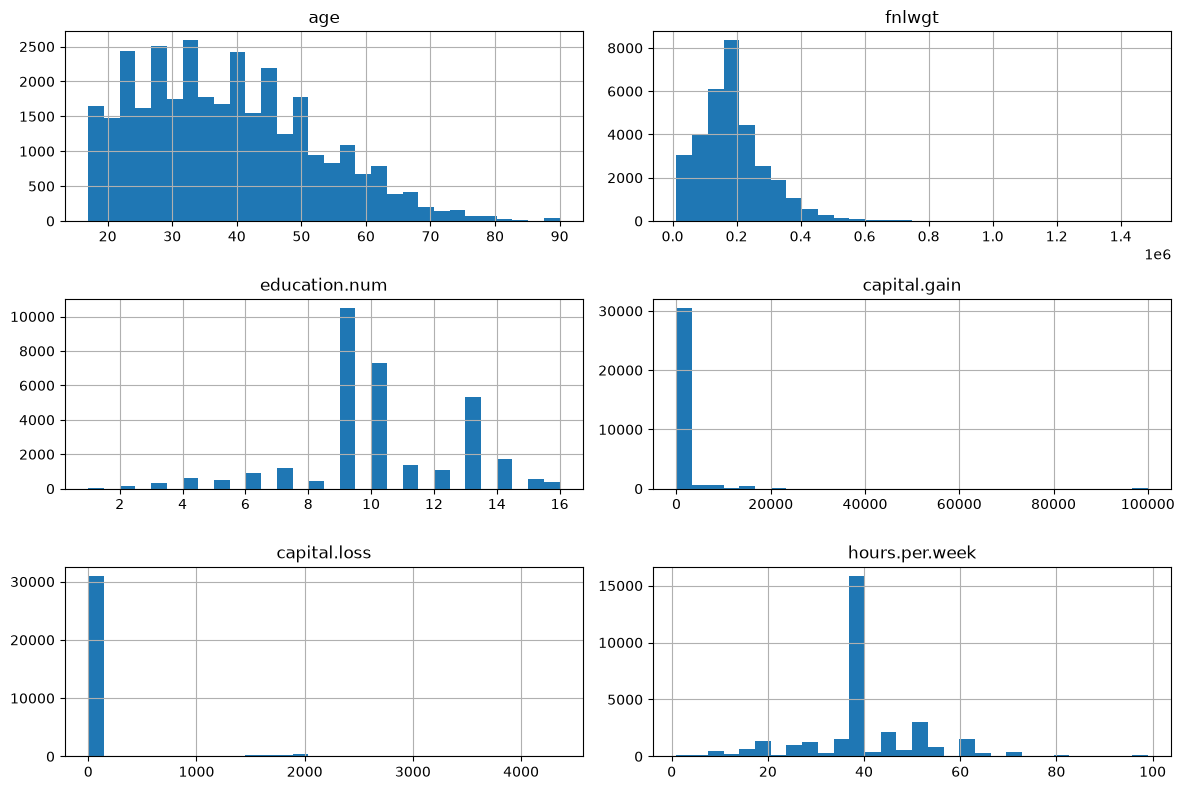

In [27]:
# Question: what shape does each numerical feature have?
df[numerical_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

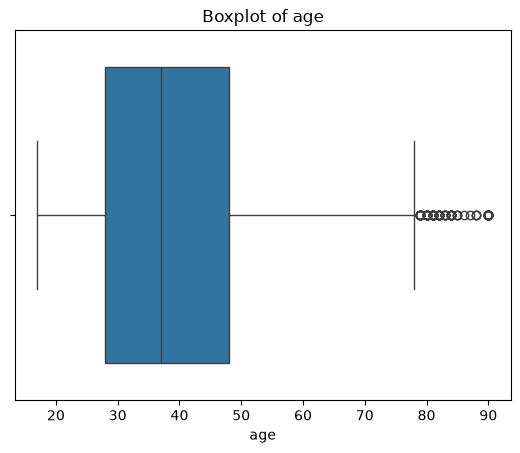

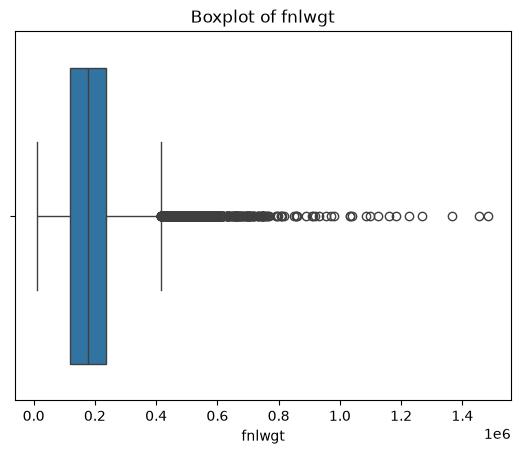

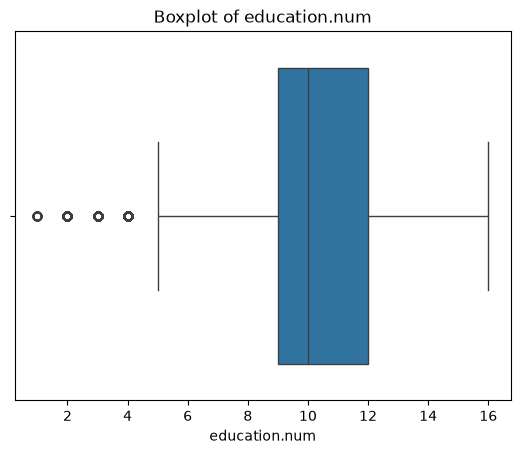

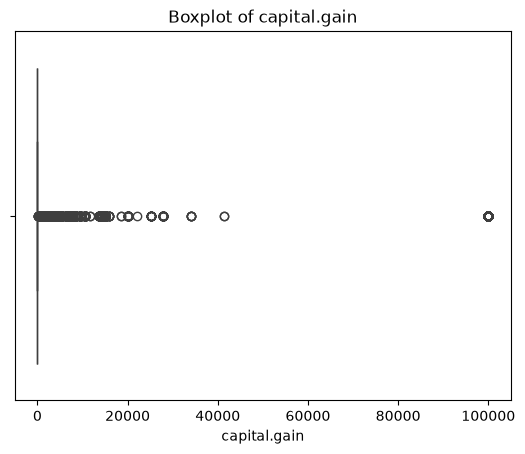

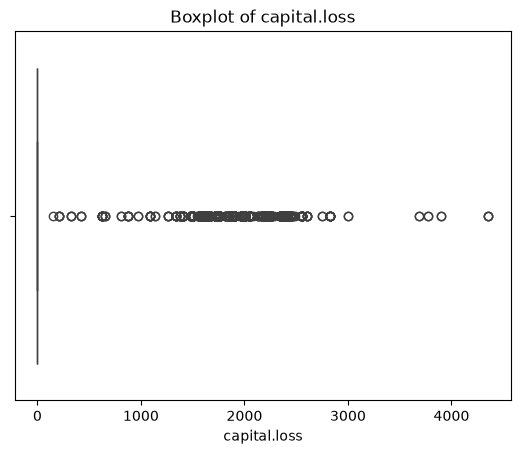

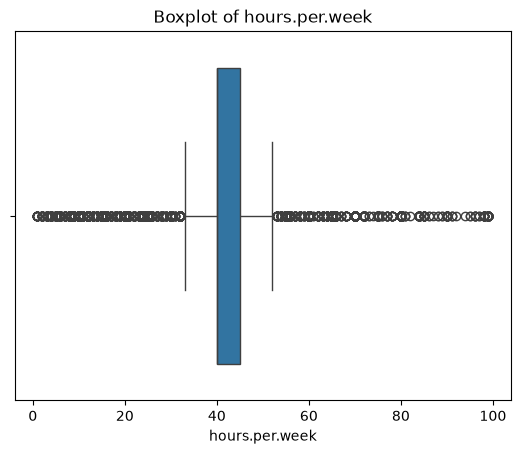

In [28]:
# Boxplots to look for extreme values
for col in numerical_cols:
    sns.boxplot(data=df, x=col)
    plt.title('Boxplot of ' + col)
    plt.show()

In [29]:
# Count how many values the IQR rule would classify as outliers
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, len(outliers), round(len(outliers) / len(df) * 100, 2), '%')

age 142 0.44 %
fnlwgt 993 3.05 %
education.num 1193 3.67 %
capital.gain 2712 8.34 %
capital.loss 1519 4.67 %
hours.per.week 9002 27.67 %


In [30]:
# Before removing anything, check whether extreme working hours are informative
short_hours = df[df['hours.per.week'] < 32]
normal_hours = df[(df['hours.per.week'] >= 32) & (df['hours.per.week'] <= 52)]
long_hours = df[df['hours.per.week'] > 52]

print('under 32 hours:', len(short_hours), round(short_hours['high_income'].mean() * 100, 1), '%')
print('32 to 52 hours:', len(normal_hours), round(normal_hours['high_income'].mean() * 100, 1), '%')
print('over 52 hours: ', len(long_hours), round(long_hours['high_income'].mean() * 100, 1), '%')

under 32 hours: 5245 6.7 %
32 to 52 hours: 23801 25.3 %
over 52 hours:  3491 41.6 %


In [31]:
# These two columns are mostly zero, so check what the non-zero values mean
print('capital.gain is zero in', round((df['capital.gain'] == 0).mean() * 100, 2), '% of rows')
print('capital.loss is zero in', round((df['capital.loss'] == 0).mean() * 100, 2), '% of rows')

capital.gain is zero in 91.66 % of rows
capital.loss is zero in 95.33 % of rows


In [32]:
# Compare income rates for people with and without capital gains
no_gain = df[df['capital.gain'] == 0]
has_gain = df[df['capital.gain'] > 0]
capped = df[df['capital.gain'] == 99999]

print('no capital gain:  ', len(no_gain), round(no_gain['high_income'].mean() * 100, 1), '%')
print('has capital gain: ', len(has_gain), round(has_gain['high_income'].mean() * 100, 1), '%')
print('capital gain 99999:', len(capped), round(capped['high_income'].mean() * 100, 1), '%')

no capital gain:   29825 20.7 %
has capital gain:  2712 61.8 %
capital gain 99999: 159 100.0 %


In [33]:
# fnlwgt is a census sampling weight, so check whether it relates to income at all
print(df.groupby('income')['fnlwgt'].mean().round(0))

income
<=50K    190346.0
>50K     188000.0
Name: fnlwgt, dtype: float64


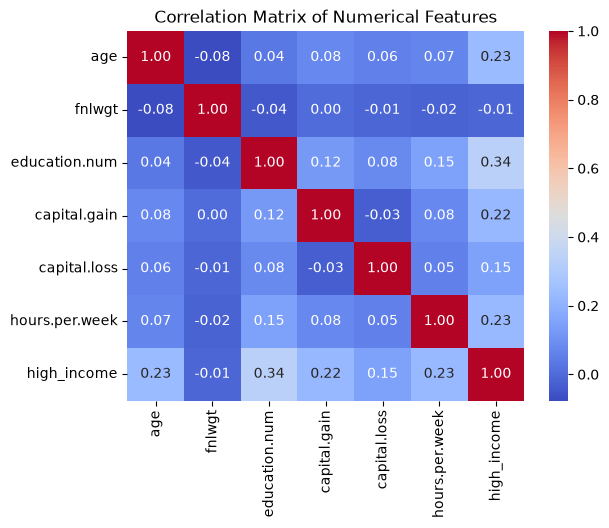

In [34]:
# Correlation between the numerical features and the target
correlation = df[numerical_cols + ['high_income']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [35]:
# Check whether education and education.num contain the same information
print(df[['education', 'education.num']].drop_duplicates().sort_values('education.num'))

         education  education.num
1106     Preschool              1
26         1st-4th              2
27         5th-6th              3
3          7th-8th              4
197            9th              5
6             10th              6
16            11th              7
178           12th              8
0          HS-grad              9
2     Some-college             10
25       Assoc-voc             11
18      Assoc-acdm             12
12       Bachelors             13
13         Masters             14
11     Prof-school             15
7        Doctorate             16


In [36]:
# Confirm the mapping is one-to-one in both directions
print(df.groupby('education')['education.num'].nunique().max())
print(df.groupby('education.num')['education'].nunique().max())

1
1


### Insights: Numerical Features

- **`education.num` has the strongest linear relationship with income** (r = 0.335), followed by `age` (0.234), `hours.per.week` (0.230) and `capital.gain` (0.223).
- **No multicollinearity is present.** The highest correlation between any two numerical features is 0.148, so no numerical feature needs to be removed for redundancy.
- **`capital.gain` and `capital.loss` are extremely skewed** (skewness 11.95 and 4.59), being zero in 91.66% and 95.33% of rows respectively. The non-zero values are nevertheless highly informative: 61.8% of individuals with any capital gain earn above $50K, compared with 20.7% of those with none. The 159 records with a value of exactly 99,999 are a census top-code rather than a true amount, and **all 159 earn above $50K**.
- **`fnlwgt` shows no relationship with income** (r = −0.010; class means of 190,346 and 188,000).

### Decisions

**1. Outliers are retained.** The IQR rule flags 27.67% of `hours.per.week` values as outliers, which reflects the fact that the distribution is heavily concentrated at exactly 40 hours rather than the presence of erroneous data. These values are also strongly informative: 41.6% of those working over 52 hours per week earn above $50K, compared with 25.3% in the 32–52 hour range and 6.7% below 32 hours. Removing them would discard genuine signal, so no outlier treatment is applied.

**2. `capital.gain` and `capital.loss` will be log-transformed** using `log1p`, which handles zero values directly. This reduces the extreme skew so that distance-based and linear models (Logistic Regression, SVM, KNN) are not dominated by a single feature, while preserving the full ordering. The transformation is monotonic, so tree-based models are unaffected. The 99,999 records are kept, since they represent the clearest high-income signal in the dataset.

**3. `fnlwgt` will be dropped.** It is a survey sampling weight describing how many people in the population each record represents, not a characteristic of the individual. It has essentially no relationship with income (r = −0.010), and it would not be available for a new individual at prediction time, which makes it unusable for the stated business objective.

**4. `education` will be dropped and `education.num` retained.** The two columns are a perfect one-to-one mapping across all 16 education levels. `education.num` captures the same information in a single ordered column, whereas one-hot encoding `education` would create 15 columns and discard the ordering.

These four decisions are applied in the preprocessing section.

# 3. Feature Selection

We assess each feature formally before deciding what enters the model. Numerical features are assessed using the correlation matrix in Section 2.2. Categorical features are assessed here using the chi-square test of independence.

**Hypotheses for each test:**

- **H0:** The categorical feature and `income` are independent (no relationship).
- **H1:** The categorical feature and `income` are not independent (a relationship exists).

We reject H0 when the p-value is below 0.05.

An important limitation of the p-value must be noted. The chi-square test measures whether *any* association exists, not how strong it is. With 32,537 records the test is powerful enough to detect associations too weak to be practically useful. We therefore also report **Cramér's V**, an effect size measure ranging from 0 to 1 that does not increase with sample size, and use it to compare the strength of each relationship.

In [37]:
from scipy.stats import chi2_contingency

categorical_cols = ['workclass', 'marital.status', 'occupation',
                    'relationship', 'race', 'sex', 'native.country']

results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df['income'])
    chi2, p_value, dof, expected = chi2_contingency(table)

    # Cramer's V measures how strong the relationship is
    n = table.values.sum()
    min_dim = min(table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    results.append([col, round(chi2, 1), dof, p_value, round(cramers_v, 3)])

results = pd.DataFrame(results, columns=['feature', 'chi2', 'dof', 'p_value', 'cramers_v'])
results = results.sort_values('cramers_v', ascending=False)

print(results.to_string(index=False))

       feature   chi2  dof       p_value  cramers_v
  relationship 6692.1    5  0.000000e+00      0.454
marital.status 6510.3    6  0.000000e+00      0.447
    occupation 4030.2   14  0.000000e+00      0.352
           sex 1516.5    1  0.000000e+00      0.216
     workclass 1044.7    8 3.352256e-220      0.179
          race  330.9    4  2.279787e-70      0.101
native.country  315.4   41  4.833086e-44      0.098


In [38]:
# A control test: create a column of random groups with no real relationship
np.random.seed(0)
random_column = np.random.choice(['A', 'B', 'C', 'D', 'E'], size=len(df))

table = pd.crosstab(random_column, df['income'])
chi2, p_value, dof, expected = chi2_contingency(table)

print('random column chi2:', round(chi2, 2), 'p-value:', round(p_value, 4))

random column chi2: 5.0 p-value: 0.2874


In [39]:
# The chi-square test assumes expected counts of at least 5 in most cells.
# native.country has 42 categories, so we check whether this holds.
table = pd.crosstab(df['native.country'], df['income'])
chi2, p_value, dof, expected = chi2_contingency(table)

print('smallest expected count:', round(expected.min(), 2))
print('cells with expected count below 5:', (expected < 5).sum(), 'out of', expected.size)

smallest expected count: 0.24
cells with expected count below 5: 12 out of 84


In [40]:
# Group native.country into two categories so the test assumption is satisfied
df['native_country_grouped'] = np.where(df['native.country'] == 'United-States',
                                        'United-States', 'Other')

print(df['native_country_grouped'].value_counts())
print(df.groupby('native_country_grouped')['high_income'].mean().round(3) * 100)

native_country_grouped
United-States    29153
Other             3384
Name: count, dtype: int64
native_country_grouped
Other            19.8
United-States    24.6
Name: high_income, dtype: float64


In [41]:
# Re-run the chi-square test on the grouped version
table = pd.crosstab(df['native_country_grouped'], df['income'])
chi2, p_value, dof, expected = chi2_contingency(table)

print('chi2:', round(chi2, 1))
print('p-value:', p_value)
print('smallest expected count:', round(expected.min(), 0))

chi2: 37.8
p-value: 7.804143463331444e-10
smallest expected count: 815.0


### Chi-Square Results

| Feature | χ² | dof | p-value | Cramér's V |
|---|---|---|---|---|
| `relationship` | 6,692.1 | 5 | < 0.001 | 0.454 |
| `marital.status` | 6,510.3 | 6 | < 0.001 | 0.447 |
| `occupation` | 4,030.2 | 14 | < 0.001 | 0.352 |
| `sex` | 1,516.5 | 1 | < 0.001 | 0.216 |
| `workclass` | 1,044.7 | 8 | < 0.001 | 0.179 |
| `race` | 330.9 | 4 | < 0.001 | 0.101 |
| `native.country` | 315.4 | 41 | < 0.001 | 0.098 |

**Interpretation.** H0 is rejected for every categorical feature, so all of them have a statistically detectable relationship with income. However, the p-values cannot be used to rank the features. `native.country` has a Cramér's V of only 0.098, indicating a very weak association, yet still returns a p-value below 0.001 because the sample size is large enough to detect it.

To confirm this is a property of sample size rather than a fault in the test, we applied the same test to a column of randomly assigned groups. It returned χ² = 5.00 with p = 0.287, correctly indicating no relationship. The test therefore behaves as expected; the issue is that with 32,537 records, both very weak and very strong real relationships produce p-values near zero.

**Ranking by Cramér's V:** `relationship` and `marital.status` are the strongest categorical predictors, followed by `occupation`. `race` and `native.country` are the weakest.

### Decisions

**1. `native.country` is grouped into `United-States` and `Other`.** With 42 categories and 89.6% of records from the United States, 12 of 84 expected cell counts fall below 5, violating a chi-square assumption. Grouping raises the smallest expected count to 815, making the test valid (χ² = 37.8, p < 0.001). It also reduces 41 one-hot columns to a single column. The association remains weak (V = 0.034), so this feature contributes little, but it is retained because "born in the United States" has a clear interpretation.

**2. `race` and `sex` are retained.** Both are statistically significant with weak-to-moderate effect sizes. Retaining them requires an explicit note. As shown in Section 2.1, the `relationship` categories `Husband` and `Wife` are almost perfectly determined by sex (13,186 of 13,187 `Husband` records are male). Removing the `sex` column would therefore not produce a model that ignores gender; the information would still reach the model through `relationship` as a proxy. We keep both features and address the implications directly in the discussion rather than removing a column in a way that would create a misleading impression of neutrality.

**3. All other categorical features are retained**, as each shows a statistically significant relationship with a meaningful effect size.

### Final Feature Set

**Numerical (5):** `age`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`

**Categorical (7):** `workclass`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native_country_grouped`

**Removed:** `fnlwgt` (survey weight, r = −0.010), `education` (duplicate of `education.num`), `native.country` (replaced by the grouped version)

**Target:** `income`, converted to a binary variable where 1 indicates income above $50K

# 4. Data Preprocessing

We now apply the decisions made during exploratory analysis and feature selection, and prepare the data for modelling.

In [42]:
# Keep an untouched copy of the original capital columns.
# This prevents log1p from being applied twice if this cell is re-run.
if 'capital_gain_original' not in globals():
    capital_gain_original = df['capital.gain'].copy()
    capital_loss_original = df['capital.loss'].copy()

# Apply the transformation from the original values each time
df['capital.gain'] = np.log1p(capital_gain_original)
df['capital.loss'] = np.log1p(capital_loss_original)

# Check the effect on skewness
print(df[['capital.gain', 'capital.loss']].skew().round(2))

capital.gain    3.09
capital.loss    4.31
dtype: float64


In [43]:
# The features selected in Section 3.
# fnlwgt, education and native.country are excluded for the reasons documented there.
features = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week',
            'workclass', 'marital.status', 'occupation', 'relationship',
            'race', 'sex', 'native_country_grouped']

X = df[features]

# Target: 1 if the person earns more than 50K, otherwise 0
y = df['high_income']

print(X.shape)
print(y.value_counts())

(32537, 12)
high_income
0    24698
1     7839
Name: count, dtype: int64


In [44]:
# Convert the categorical features into numeric columns using one-hot encoding.
# drop_first=True removes one category per feature to avoid redundant columns.
X = pd.get_dummies(X, drop_first=True)

print('Number of features after encoding:', X.shape[1])
print(X.columns.tolist())

Number of features after encoding: 44
['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital.status_Married-AF-spouse', 'marital.status_Married-civ-spouse', 'marital.status_Married-spouse-absent', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'occupation_Unknown', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationsh

In [45]:
from sklearn.model_selection import train_test_split

# stratify=y keeps the same proportion of high earners in both sets,
# which matters because the target is imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print('High earners in training set:', round(y_train.mean() * 100, 2), '%')
print('High earners in test set:', round(y_test.mean() * 100, 2), '%')

Training set: (26029, 44)
Test set: (6508, 44)
High earners in training set: 24.09 %
High earners in test set: 24.09 %


In [46]:
# Confirm that every encoded column appears in both sets,
# since some categories are very rare (for example Never-worked has only 7 rows)
print('Empty columns in training set:', (X_train.sum() == 0).sum())
print('Empty columns in test set:', (X_test.sum() == 0).sum())

Empty columns in training set: 0
Empty columns in test set: 0


### Preprocessing Decisions

**1. Log transformation of the capital columns.** `capital.gain` and `capital.loss` are extremely skewed and operate on a far larger scale than the other numerical features. Applying `log1p` reduces the skewness of `capital.gain` from 11.95 to 3.09, and reduces the standard deviation of `capital.loss` from 403.1 to 1.59.

The skewness of `capital.loss` changes only slightly (4.59 to 4.31), because its skew is caused by the 95.33% of rows containing zero rather than by the range of the non-zero values. The transformation is still applied to both columns because the main benefit is bringing them onto a scale comparable with the other features, which matters for the distance-based and linear models. The transformation is monotonic and therefore has no effect on tree-based models.

**2. Encoding is applied before the train/test split; scaling is applied after.**

These two steps are treated differently because they learn different things from the data. One-hot encoding only records which category names exist; it computes no statistics and extracts no information about the target, so applying it to the full dataset does not cause data leakage. It does, however, guarantee that the training and test sets have identical columns. This matters here because several categories are very rare — `Never-worked` has 7 records and `Without-pay` has 14 — and encoding the two sets separately could produce mismatched columns.

Scaling is different. `StandardScaler` calculates the mean and standard deviation from the data, and if these were computed using the test set the model would gain information it should not have. Scaling is therefore fitted on the training data only.

**3. Scaling is applied inside a Pipeline rather than as a separate step.** `GridSearchCV` splits the training data again into cross-validation folds. If the scaler were fitted once on the whole training set beforehand, each internal validation fold would have contributed to the mean and standard deviation used to transform it. Placing the scaler inside a Pipeline makes scikit-learn refit it separately within every fold, which removes this leakage. Scaling is applied only to Logistic Regression, SVM and KNN; tree-based models are unaffected by feature scale.

**4. The split uses stratification.** With only 24.09% of records in the positive class, a random split could produce noticeably different class proportions in the two sets. Using `stratify=y` preserves 24.09% in both.

Feature engineering focused on transformations that improved data usability without unnecessarily increasing model complexity. These included `log1p` transformation for skewed capital variables, grouping rare native-country categories, handling missing values through an `Unknown` category, and one-hot encoding categorical variables. No additional derived features were introduced because the existing variables already captured the main predictive patterns and maintaining a consistent feature set allowed fair comparison across all models.

### Result

- **44 features** after one-hot encoding
- **26,029 training records** and **6,508 test records**
- Class balance preserved: 24.09% high earners in both sets

The test set is not used for model fitting, hyperparameter tuning, or model selection. These decisions are based on the training data and cross-validation. The test set is used only to report and compare generalisation performance after each model has been trained and tuned.

# 5. Model Building

## 5.1 Baseline Models

Before building and tuning any model, we establish two reference points.

The first is a **naive baseline** that always predicts the majority class. This shows what performance can be achieved without learning anything from the features, and confirms that any later result represents genuine learning.

The second is an **untuned Logistic Regression**, which shows what a simple model achieves before any hyperparameter tuning. Every subsequent model is compared against both.

In [47]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Evaluate all models using the same metrics.
# Models with predict_proba use probabilities; SVM falls back to decision_function.
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    print(name)
    print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
    print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
    print('Recall   :', round(recall_score(y_test, y_pred), 4))
    print('F1 Score :', round(f1_score(y_test, y_pred), 4))
    print('ROC-AUC  :', round(roc_auc_score(y_test, y_score), 4))
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print()

In [48]:
from sklearn.dummy import DummyClassifier

# A model that always predicts the majority class (<=50K)
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

evaluate_model('Baseline: Majority Class', dummy, X_test, y_test)

Baseline: Majority Class
Accuracy : 0.7591
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.5
Confusion Matrix:
[[4940    0]
 [1568    0]]



In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features, so the scaler is placed
# inside a Pipeline. This ensures it is refitted correctly during
# cross-validation later, using only the training portion of each fold.
logreg_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_base.fit(X_train, y_train)

evaluate_model('Logistic Regression (untuned)', logreg_base, X_test, y_test)

Logistic Regression (untuned)
Accuracy : 0.8457
Precision: 0.7176
Recall   : 0.5931
F1 Score : 0.6494
ROC-AUC  : 0.8954
Confusion Matrix:
[[4574  366]
 [ 638  930]]



In [50]:
# Approach 1: class_weight='balanced' gives more importance to the minority class
logreg_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

logreg_balanced.fit(X_train, y_train)

evaluate_model('Logistic Regression (class_weight=balanced)', logreg_balanced, X_test, y_test)

Logistic Regression (class_weight=balanced)
Accuracy : 0.8035
Precision: 0.5625
Recall   : 0.8297
F1 Score : 0.6704
ROC-AUC  : 0.8956
Confusion Matrix:
[[3928 1012]
 [ 267 1301]]



In [51]:
# Approach 2: SMOTE creates synthetic examples of the minority class.
# We test it here to decide whether it is worth using.
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

logreg_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_smote.fit(X_train, y_train)

evaluate_model('Logistic Regression (SMOTE)', logreg_smote, X_test, y_test)

Logistic Regression (SMOTE)
Accuracy : 0.8049
Precision: 0.5649
Recall   : 0.8272
F1 Score : 0.6713
ROC-AUC  : 0.8954
Confusion Matrix:
[[3941  999]
 [ 271 1297]]



### Baseline Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Majority class | 0.7591 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |
| Logistic Regression (untuned) | 0.8457 | 0.7176 | 0.5931 | 0.6494 | 0.8954 |

The majority-class baseline achieves 75.91% accuracy while identifying **none** of the 1,568 high earners in the test set. Its ROC-AUC of exactly 0.5000 correctly reflects that it has no ability to distinguish between the two groups. This confirms the concern raised in Section 1.5: accuracy alone is not an adequate measure for this problem.

The untuned Logistic Regression reaches a ROC-AUC of 0.8954, which is a substantial improvement and establishes the standard that the tuned models must exceed. However, its recall of 0.5931 means it identifies only 930 of the 1,568 high earners and misses 638. Given that missing a qualified prospect is the more costly error in our problem framing, this is the weakness that later work needs to address.

### Handling Class Imbalance

We compared three approaches using the baseline model.

| Approach | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| No adjustment | 0.8457 | 0.7176 | 0.5931 | 0.6494 | 0.8954 |
| `class_weight='balanced'` | 0.8035 | 0.5625 | 0.8297 | 0.6704 | 0.8956 |
| SMOTE oversampling | 0.8049 | 0.5649 | 0.8272 | 0.6713 | 0.8954 |
**The ROC-AUC is effectively unchanged across all three approaches (0.8954, 0.8956, 0.8954).** Neither technique improves the model's ability to rank individuals by their likelihood of earning above $50K. What changes is the balance between precision and recall: recall rises from 0.59 to 0.83 while precision falls from 0.72 to 0.56. This is a shift in the effective decision threshold rather than an improvement in the model itself.

**Decision: SMOTE is not used.**

It produced no improvement in ROC-AUC over the simpler `class_weight` option, and it has a specific drawback for this dataset. SMOTE generates synthetic minority records by interpolating between existing ones. Our feature set consists largely of 44 one-hot encoded columns, so interpolation produces records that are fractionally in several categories at once — for example partly `Husband` and partly `Wife`, or between `Doctorate` and `HS-grad`. These do not correspond to people who could exist. It also adds an external dependency and increases training time during cross-validation, without a measurable benefit.

**Decision: class weighting is considered where supported and computationally appropriate, rather than fixed in advance.**

Its effect is not consistent across model types. `class_weight` is included in the Logistic Regression and Decision Tree searches, where cross-validation can decide whether it helps. It is excluded from the Random Forest grid to keep the search time manageable after baseline evidence showed no improvement in ranking quality. XGBoost uses `scale_pos_weight` instead of `class_weight`; this was tested separately and excluded because it did not improve ROC-AUC. KNN does not support class weighting.

**Decision: the precision–recall trade-off is handled by explicit threshold tuning.**

Because all three approaches produce nearly identical ranking quality, the choice of operating point is best made directly and transparently after the final model is selected. This is carried out in Section 6 using cross-validated predictions on the training data, so that the test set remains unused until the final evaluation.

## 5.2 Model 1: Logistic Regression

Logistic Regression is used as our primary model and reference point. It is a linear model that estimates the probability of the positive class, and it has two properties that make it a good starting point: it trains quickly, and its coefficients can be read directly to see which features push a prediction in which direction.

**Hyperparameters tuned:**

- **`C`** controls regularisation strength. A small value applies strong regularisation, shrinking the coefficients towards zero and reducing the risk of overfitting. A large value allows the model to fit the training data more closely.
* **`l1_ratio`** controls the balance between L1 and L2 regularization.
- **`class_weight`** is included as a search value rather than fixed in advance, following the decision in Section 5.1.

The scaler is placed inside the Pipeline so that it is refitted on the training portion of each cross-validation fold, preventing information from the validation fold influencing the transformation.

Scoring uses `roc_auc`, as committed in Section 1.5.

In [52]:
from sklearn.model_selection import GridSearchCV

# Pipeline: scale the features, then fit Logistic Regression
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000, solver='liblinear', random_state=42))
])

# liblinear supports both L1 and L2 regularisation
# In scikit-learn 1.8+, l1_ratio is used instead of the deprecated penalty parameter
logreg_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [1, 0],
    'model__class_weight': [None, 'balanced']
}
logreg_search = GridSearchCV(logreg_pipe, logreg_grid, scoring='roc_auc', cv=5, n_jobs=-1)
logreg_search.fit(X_train, y_train)

print('Best parameters:', logreg_search.best_params_)
print('Best cross-validation ROC-AUC:', round(logreg_search.best_score_, 4))

Best parameters: {'model__C': 0.1, 'model__class_weight': None, 'model__l1_ratio': 0}
Best cross-validation ROC-AUC: 0.9009


In [53]:
# Keep the best version for the final comparison
logreg_best = logreg_search.best_estimator_

evaluate_model('Logistic Regression (tuned)', logreg_best, X_test, y_test)

Logistic Regression (tuned)
Accuracy : 0.8453
Precision: 0.7159
Recall   : 0.5931
F1 Score : 0.6488
ROC-AUC  : 0.8956
Confusion Matrix:
[[4571  369]
 [ 638  930]]



In [55]:
# Compare every parameter combination to see how much the choice mattered
results = pd.DataFrame(logreg_search.cv_results_)

# Automatically collect all parameters used in GridSearch
param_columns = [
    col for col in results.columns
    if col.startswith('param_')
]

results = results[param_columns + ['mean_test_score']]

print(
    results
    .sort_values('mean_test_score', ascending=False)
    .round(4)
    .to_string(index=False)
)

 param_model__C param_model__class_weight  param_model__l1_ratio  mean_test_score
           0.10                       NaN                      0           0.9009
           0.01                       NaN                      0           0.9008
           1.00                       NaN                      1           0.9008
           0.01                  balanced                      0           0.9008
           0.10                       NaN                      1           0.9008
           1.00                       NaN                      0           0.9008
           0.10                  balanced                      0           0.9008
          10.00                       NaN                      0           0.9008
         100.00                       NaN                      0           0.9008
          10.00                       NaN                      1           0.9008
         100.00                       NaN                      1           0.9008
           1.00 

In [56]:
# The range between the best and worst combination
print('Best  CV score:', round(results['mean_test_score'].max(), 4))
print('Worst CV score:', round(results['mean_test_score'].min(), 4))
print('Difference    :', round(results['mean_test_score'].max() - results['mean_test_score'].min(), 4))

Best  CV score: 0.9009
Worst CV score: 0.8991
Difference    : 0.0018


In [57]:
# The coefficients show how each feature affects the prediction.
# Because the features were standardised, the values are directly comparable.
coefficients = pd.Series(logreg_best.named_steps['model'].coef_[0], index=X_train.columns)
coefficients = coefficients.sort_values()

print('Strongest negative influence (towards <=50K):')
print(coefficients.head(10).round(3))
print()
print('Strongest positive influence (towards >50K):')
print(coefficients.tail(10).round(3))

Strongest negative influence (towards <=50K):
relationship_Own-child         -0.431
occupation_Other-service       -0.284
workclass_Self-emp-not-inc     -0.236
marital.status_Never-married   -0.208
workclass_Private              -0.205
occupation_Farming-fishing     -0.176
workclass_State-gov            -0.172
workclass_Local-gov            -0.161
occupation_Handlers-cleaners   -0.149
occupation_Priv-house-serv     -0.143
dtype: float64

Strongest positive influence (towards >50K):
occupation_Prof-specialty            0.200
capital.loss                         0.245
occupation_Exec-managerial           0.256
relationship_Wife                    0.259
age                                  0.340
hours.per.week                       0.360
sex_Male                             0.363
capital.gain                         0.512
education.num                        0.715
marital.status_Married-civ-spouse    0.786
dtype: float64


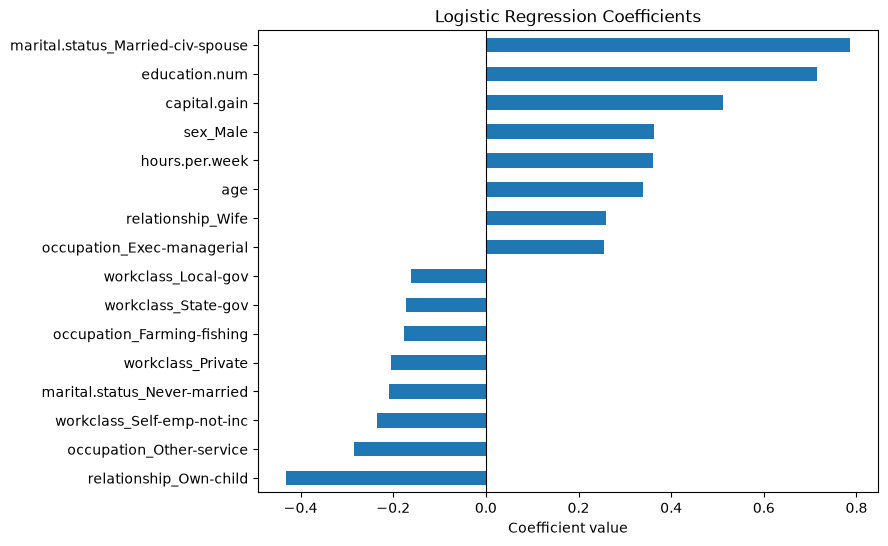

In [58]:
# Visualise the 15 most influential features in either direction
top_features = pd.concat([coefficients.head(8), coefficients.tail(8)])

top_features.plot(kind='barh', figsize=(8, 6))
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient value')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

### Model 1 Results

| Version | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Untuned | 0.8457 | 0.7176 | 0.5931 | 0.6494 | 0.8954 |
| Tuned (GridSearch) | 0.8453 | 0.7159 | 0.5931 | 0.6488 | 0.8956 |

**Best parameters:** `C = 0.1`, `l1_ratio = 0` (equivalent to L2 regularisation), `class_weight = None`
**Best cross-validation ROC-AUC:** 0.9009

**Tuning produced almost no improvement**, raising test ROC-AUC from 0.8954 to 0.8956. This is not a failure of the search. Across all 20 parameter combinations tested, cross-validation scores ranged only from 0.8991 to 0.9009 — a difference of 0.0018. The choice of hyperparameters had almost no effect on performance.

The reason is structural. Logistic Regression fits a single linear decision boundary and has limited flexibility, so it is unlikely to overfit. With 26,029 training records and 44 features — approximately 590 records per feature — there is little variance for regularisation to control.Since `C` and `l1_ratio` exist to limit overfitting, they have little work to do here.

This result also provides a useful expectation for the models that follow. Tree-based models have hyperparameters such as depth and minimum sample counts that directly control model complexity, so tuning should matter considerably more for them. A large improvement there alongside a negligible improvement here is the expected pattern rather than an inconsistency.

`class_weight='balanced'` was not selected by the search, consistent with the finding in Section 5.1 that class reweighting alters the precision–recall balance without improving the model's ranking quality, which is what ROC-AUC measures.

### Features Influencing the Model

Because the features were standardised before fitting, the coefficients are directly comparable in size.

| Increases probability of >50K | Coefficient | Decreases probability of >50K | Coefficient |
|---|---|---|---|
| `marital.status_Married-civ-spouse` | +0.786 | `relationship_Own-child` | −0.431 |
| `education.num` | +0.715 | `occupation_Other-service` | −0.284 |
| `capital.gain` | +0.512 | `workclass_Self-emp-not-inc` | −0.236 |
| `sex_Male` | +0.363 | `marital.status_Never-married` | −0.208 |
| `hours.per.week` | +0.360 | `workclass_Private` | −0.205 |
| `age` | +0.340 | `occupation_Farming-fishing` | −0.176 |

These results align with the exploratory analysis. Marital status is the strongest single influence, followed by education level and capital gains. The presence of `sex_Male` (+0.363) alongside `relationship_Wife` (+0.259) illustrates the point raised in Section 3: gender information reaches the model through both the `sex` column and the `relationship` categories.

The model's recall of 0.5931 remains its main weakness, identifying 930 of 1,568 high earners in the test set. This is addressed through threshold adjustment in Section 6.

## 5.3 Model 2: Decision Tree

A Decision Tree splits the data repeatedly on feature values, producing a set of rules that can be read directly. Unlike Logistic Regression it can capture non-linear relationships and interactions between features without those being specified in advance.

Its weakness is the opposite of Logistic Regression's. Left unrestricted, a tree will continue splitting until each leaf contains almost pure cases, effectively memorising the training data. The hyperparameters we tune all serve to limit this.

**Hyperparameters tuned:**

- **`max_depth`** limits how many levels the tree may grow. This is the main control on model complexity.
- **`min_samples_split`** sets the minimum number of records a node must contain before it is allowed to split further.
- **`min_samples_leaf`** sets the minimum number of records that must remain in a final leaf, preventing rules based on only one or two individuals.
- **`class_weight`** is included as a search value, as decided in Section 5.1.

No scaling is applied. Decision Trees split on thresholds within individual features, so the scale of a feature does not affect the result.

In [59]:
from sklearn.tree import DecisionTreeClassifier

# An unrestricted tree, to show what happens without any limits
tree_base = DecisionTreeClassifier(random_state=42)
tree_base.fit(X_train, y_train)

print('Tree depth :', tree_base.get_depth())
print('Number of leaves:', tree_base.get_n_leaves())
print('Training accuracy:', round(tree_base.score(X_train, y_train), 4))
print()

evaluate_model('Decision Tree (untuned)', tree_base, X_test, y_test)

Tree depth : 43
Number of leaves: 4550
Training accuracy: 0.9791

Decision Tree (untuned)
Accuracy : 0.8161
Precision: 0.6228
Recall   : 0.6001
F1 Score : 0.6112
ROC-AUC  : 0.7602
Confusion Matrix:
[[4370  570]
 [ 627  941]]



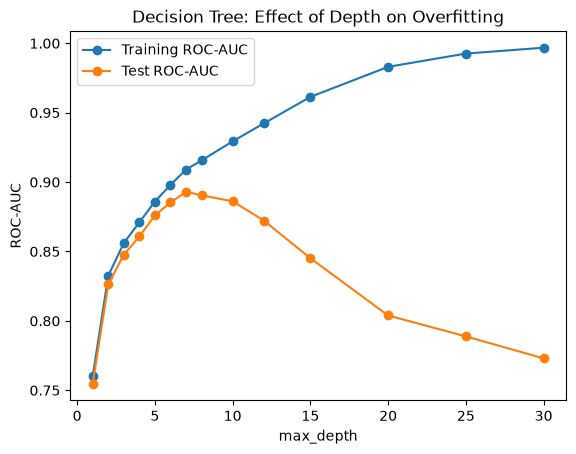

In [60]:
# Question: how does tree depth affect performance on training vs test data?
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30]
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))
    test_scores.append(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

plt.plot(depths, train_scores, marker='o', label='Training ROC-AUC')
plt.plot(depths, test_scores, marker='o', label='Test ROC-AUC')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Decision Tree: Effect of Depth on Overfitting')
plt.legend()
plt.show()

In [61]:
tree_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 20],
    'class_weight': [None, 'balanced']
}

tree_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           tree_grid, scoring='roc_auc', cv=5, n_jobs=-1)
tree_search.fit(X_train, y_train)

print('Best parameters:', tree_search.best_params_)
print('Best cross-validation ROC-AUC:', round(tree_search.best_score_, 4))

Best parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 50}
Best cross-validation ROC-AUC: 0.9066


In [62]:
tree_best = tree_search.best_estimator_

# Compare the size of the tuned tree against the unrestricted one
print('Tuned tree depth :', tree_best.get_depth())
print('Number of leaves :', tree_best.get_n_leaves())
print('Training accuracy:', round(tree_best.score(X_train, y_train), 4))
print()

evaluate_model('Decision Tree (tuned)', tree_best, X_test, y_test)

Tuned tree depth : 10
Number of leaves : 151
Training accuracy: 0.8668

Decision Tree (tuned)
Accuracy : 0.854
Precision: 0.7655
Recall   : 0.5682
F1 Score : 0.6523
ROC-AUC  : 0.8979
Confusion Matrix:
[[4667  273]
 [ 677  891]]



marital.status_Married-civ-spouse    0.3995
education.num                        0.2175
capital.gain                         0.1924
capital.loss                         0.0665
age                                  0.0449
hours.per.week                       0.0304
occupation_Exec-managerial           0.0157
workclass_Self-emp-not-inc           0.0088
relationship_Wife                    0.0053
occupation_Prof-specialty            0.0047
dtype: float64


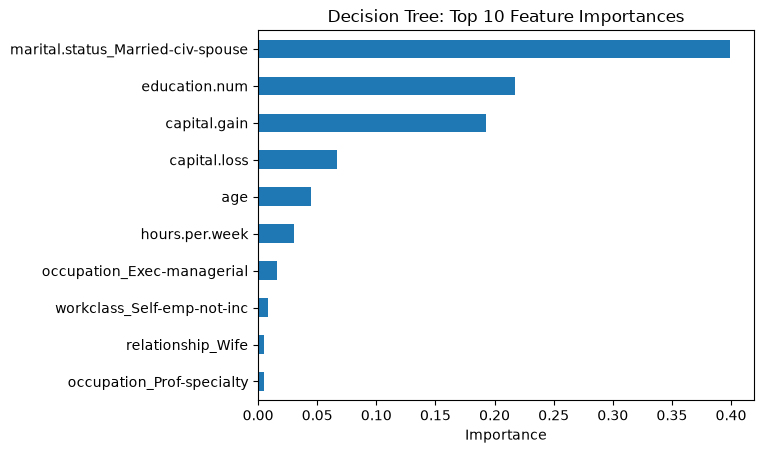

In [63]:
# Which features did the tree use most to split the data?
tree_importance = pd.Series(tree_best.feature_importances_, index=X_train.columns)
tree_importance = tree_importance.sort_values(ascending=False)

print(tree_importance.head(10).round(4))

tree_importance.head(10).sort_values().plot(kind='barh')
plt.title('Decision Tree: Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

### Model 2 Results

| Version | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Untuned | 0.8161 | 0.6228 | 0.6001 | 0.6112 | 0.7602 |
| Tuned (GridSearch) | 0.8540 | 0.7655 | 0.5682 | 0.6523 | 0.8979 |

**Best parameters:** `max_depth = 10`, `min_samples_leaf = 5`, `min_samples_split = 50`, `class_weight = None`
**Best cross-validation ROC-AUC:** 0.9066

**Tuning improved test ROC-AUC from 0.7602 to 0.8979, an increase of 0.1377.**

The untuned tree grew to a depth of 43 with 4,550 leaves and reached 97.91% accuracy on the training data, while achieving a test ROC-AUC of only 0.7602 — considerably worse than the Logistic Regression baseline. This is a clear case of overfitting: the tree had memorised the training records rather than learning patterns that generalise.

The tuned tree is restricted to a depth of 10 with 151 leaves, and its training accuracy is **lower** at 86.68%. It performs worse on data it has already seen and substantially better on data it has not, which is the intended effect of the constraints.

The depth curve above shows this directly. Training ROC-AUC rises continuously as depth increases, reaching approximately 0.9968 at `max_depth = 30`, while test ROC-AUC peaks much earlier at around depth 7 and then declines steadily. The widening gap between the two lines is the overfitting.

**Comparison with Model 1.** Tuning improved this model by 0.1377 ROC-AUC, whereas it improved Logistic Regression by only 0.0002. This difference is expected rather than inconsistent. The Decision Tree's hyperparameters directly control how complex the model may become, and an unrestricted tree can overfit severely. Logistic Regression fits a single linear boundary and has little capacity to overfit with 26,029 training records, so its regularisation parameters had little effect.

It is also worth noting that the best depth found by GridSearch (10) is not the value that appears best in the depth curve (7). The curve varies only `max_depth` while holding other parameters at their defaults, whereas GridSearch also applied `min_samples_leaf = 5` and `min_samples_split = 50`. These constraints prune the tree in a different way, and the combination performs better than restricting depth alone. This is why the parameters are searched together rather than individually.

### Features Influencing the Model

| Feature | Importance |
|---|---|
| `marital.status_Married-civ-spouse` | 0.3995 |
| `education.num` | 0.2175 |
| `capital.gain` | 0.1924 |
| `capital.loss` | 0.0665 |
| `age` | 0.0449 |
| `hours.per.week` | 0.0304 |
| `occupation_Exec-managerial` | 0.0157 |

The three most important features are the same as those identified by Logistic Regression, which provides independent confirmation from a very different algorithm.

One difference is informative. `capital.gain` carries greater importance here (0.1924) than its position in the Logistic Regression coefficients suggested. A Decision Tree can split on a threshold, allowing it to represent the pattern identified in Section 2.2 — that having *any* capital gain is what distinguishes high earners — whereas a linear model can only approximate this as a gradual effect.

## 5.4 Model 3: Random Forest

A Random Forest builds many Decision Trees and averages their predictions. Two sources of randomness make the trees differ from one another: each tree is trained on a bootstrap sample of the training rows, and at each split only a random subset of features is considered.

The purpose of this is to address the weakness identified in Section 5.3. Individual trees overfit, but each one overfits in a different way. Averaging many of them causes the individual errors to partly cancel while the patterns they agree on are retained.

**Hyperparameters tuned:**

- **`max_depth`** limits the depth of each individual tree.
- **`min_samples_leaf`** sets the minimum number of records in a final leaf, which is the main pruning control within the forest.
- **`max_features`** controls how many features each split may consider. Smaller values make the trees less similar to one another, which increases the benefit of averaging.

**`n_estimators` is fixed at 200 rather than searched.** Increasing the number of trees in a Random Forest does not cause overfitting; it reduces variance and eventually produces diminishing returns at increasing computational cost. There is therefore no optimal value to search for, only a point beyond which additional trees add little. Searching this parameter would multiply the runtime without answering a meaningful question.

**`class_weight` is not included in this grid.** Including it would double the number of model fits, and the comparison in Section 5.1 indicated that class reweighting does not improve ranking quality for tree ensembles. This is a deliberate trade-off made to keep the search time manageable, and it is noted here for transparency.

In [64]:
from sklearn.ensemble import RandomForestClassifier

# Default settings, with no restrictions on tree growth
forest_base = RandomForestClassifier(random_state=42, n_jobs=-1)
forest_base.fit(X_train, y_train)

print('Training accuracy:', round(forest_base.score(X_train, y_train), 4))

# Check how deep the individual trees grew
depths = []
for tree in forest_base.estimators_:
    depths.append(tree.get_depth())
print('Average tree depth:', round(np.mean(depths), 1))
print()

evaluate_model('Random Forest (untuned)', forest_base, X_test, y_test)

Training accuracy: 0.9791
Average tree depth: 47.0

Random Forest (untuned)
Accuracy : 0.8443
Precision: 0.7045
Recall   : 0.6097
F1 Score : 0.6537
ROC-AUC  : 0.8875
Confusion Matrix:
[[4539  401]
 [ 612  956]]



In [65]:
forest_grid = {
    'n_estimators': [200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5]
}

# n_jobs=1 on the model and n_jobs=-1 on the search gives better parallelism
forest_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),
                             forest_grid, scoring='roc_auc', cv=5, n_jobs=-1)
forest_search.fit(X_train, y_train)

print('Best parameters:', forest_search.best_params_)
print('Best cross-validation ROC-AUC:', round(forest_search.best_score_, 4))

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 200}
Best cross-validation ROC-AUC: 0.9201


In [66]:
forest_best = forest_search.best_estimator_

print('Training accuracy:', round(forest_best.score(X_train, y_train), 4))
print()

evaluate_model('Random Forest (tuned)', forest_best, X_test, y_test)

Training accuracy: 0.8795

Random Forest (tuned)
Accuracy : 0.8596
Precision: 0.7698
Recall   : 0.595
F1 Score : 0.6712
ROC-AUC  : 0.9126
Confusion Matrix:
[[4661  279]
 [ 635  933]]



In [67]:
# Compare all parameter combinations to see which settings helped
forest_results = pd.DataFrame(forest_search.cv_results_)
forest_results = forest_results[['param_max_depth', 'param_min_samples_leaf',
                                 'param_max_features', 'mean_test_score']]

print(forest_results.sort_values('mean_test_score', ascending=False).round(4).to_string(index=False))

param_max_depth  param_min_samples_leaf param_max_features  mean_test_score
           None                       5               sqrt           0.9201
             20                       5               sqrt           0.9199
             10                       1                0.5           0.9190
             20                       5                0.5           0.9190
             20                       1               sqrt           0.9190
             10                       5                0.5           0.9186
           None                       5                0.5           0.9181
           None                      20                0.5           0.9178
             20                      20                0.5           0.9178
           None                      20               sqrt           0.9166
             20                      20               sqrt           0.9165
             10                      20                0.5           0.9165
            

marital.status_Married-civ-spouse    0.1809
capital.gain                         0.1694
education.num                        0.1567
age                                  0.0929
marital.status_Never-married         0.0605
hours.per.week                       0.0558
capital.loss                         0.0442
occupation_Exec-managerial           0.0336
sex_Male                             0.0263
occupation_Prof-specialty            0.0257
dtype: float64


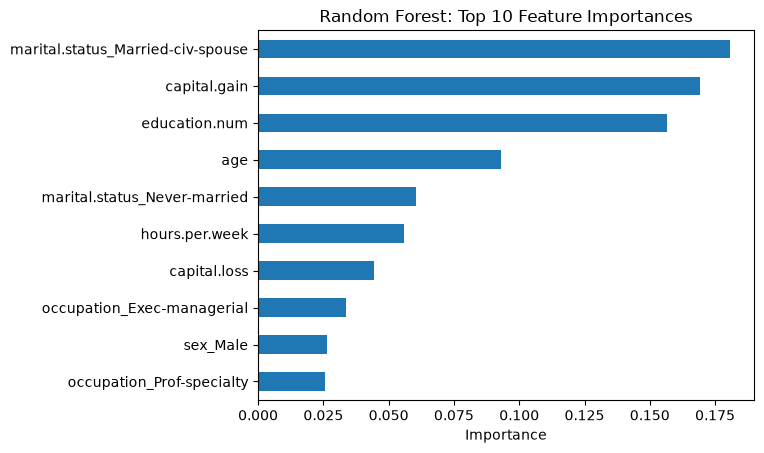

In [68]:
forest_importance = pd.Series(forest_best.feature_importances_, index=X_train.columns)
forest_importance = forest_importance.sort_values(ascending=False)

print(forest_importance.head(10).round(4))

forest_importance.head(10).sort_values().plot(kind='barh')
plt.title('Random Forest: Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

### Model 3 Results

| Version | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Untuned | 0.8443 | 0.7045 | 0.6097 | 0.6537 | 0.8875 |
| Tuned (GridSearch) | 0.8596 | 0.7698 | 0.5950 | 0.6712 | 0.9126 |

**Best parameters:** `n_estimators = 200`, `max_depth = None`, `min_samples_leaf = 5`, `max_features = 'sqrt'`
**Best cross-validation ROC-AUC:** 0.9201

**The effect of averaging, before any tuning.** The untuned Random Forest and the untuned single Decision Tree both reached a training accuracy of 0.9791, and their trees grew to comparable depths (an average of 47 for the forest, 43 for the single tree). Both therefore memorised the training data to the same degree. Despite this, the forest achieved a test ROC-AUC of 0.8875 against the single tree's 0.7602 — an improvement of 0.1273 obtained purely from averaging.

This is the mechanism the ensemble relies on. Each tree is trained on a different bootstrap sample and considers a different random subset of features at each split, so each one overfits in a different direction. Averaging causes these individual errors to partly cancel, while the patterns the trees agree on are preserved.

**The effect of tuning.** Tuning added a further 0.0251, raising test ROC-AUC from 0.8875 to 0.9126. Training accuracy fell from 0.9791 to 0.8795, confirming that the tuned model fits the training data less closely and generalises better.

Notably, the two lowest-scoring combinations in the entire search were both `max_depth = None` combined with `min_samples_leaf = 1`, which places no restriction on tree growth. The selected configuration uses `min_samples_leaf = 5`. Averaging therefore reduces overfitting substantially but does not remove it entirely, and a degree of pruning still improves results.

**Comparison across models so far:**

| Model | Test ROC-AUC | Gain from tuning |
|---|---|---|
| Logistic Regression | 0.8956 | +0.0002 |
| Decision Tree | 0.8979 | +0.1377 |
| Random Forest | 0.9126 | +0.0251 |

Random Forest leads on ROC-AUC. The size of the tuning gain in each case reflects how much each model was overfitting before tuning.

### Features Influencing the Model

| Feature | Importance |
|---|---|
| `marital.status_Married-civ-spouse` | 0.1809 |
| `capital.gain` | 0.1694 |
| `education.num` | 0.1567 |
| `age` | 0.0929 |
| `marital.status_Never-married` | 0.0605 |
| `hours.per.week` | 0.0558 |
| `capital.loss` | 0.0442 |
| `occupation_Exec-managerial` | 0.0336 |

The same three features lead as in the previous two models, but the importances are distributed much more evenly. `marital.status_Married-civ-spouse` holds an importance of 0.1809 here compared with 0.3995 in the single Decision Tree.

This does not indicate that marital status became less important. It is a consequence of `max_features = 'sqrt'`, which allows each split to consider only about 7 of the 44 features. In most splits the strongest feature is not among the options, so other features are selected instead and accumulate importance. Random Forest importances are therefore more evenly spread but less directly interpretable than those of a single tree — a reduction in interpretability that accompanies the gain in accuracy.

## 5.5 Model 4: XGBoost

XGBoost is a gradient boosting method. Unlike a Random Forest, which builds many trees independently and averages their predictions, boosting builds trees **sequentially**, with each new tree trained to correct the errors still being made by the trees before it.

This makes boosting more powerful but also more prone to overfitting, since the model can continue fitting increasingly specific errors. The hyperparameters are used to control how aggressively it learns.

**Hyperparameters tuned:**

- **`n_estimators`** is the number of sequential trees. In a Random Forest more trees is always safe, but in boosting each additional tree fits the remaining errors more closely, so too many can cause overfitting. This parameter therefore needs to be searched.
- **`max_depth`** limits the depth of each tree. Boosting typically works best with shallow trees, since each one only needs to correct a small part of the remaining error.
- **`learning_rate`** controls how much of each tree's correction is applied. A lower value means the model learns more slowly and cautiously, usually improving generalisation but requiring more trees.
- **`subsample`** is the fraction of training rows used to build each tree.
- **`colsample_bytree`** is the fraction of features made available to each tree. Both introduce randomness that reduces overfitting.

**`scale_pos_weight` is not included in the grid.** This is XGBoost's equivalent of `class_weight`, and we tested it separately below before excluding it.

In [69]:
from xgboost import XGBClassifier

# Default settings
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_base.fit(X_train, y_train)

print('Training accuracy:', round(xgb_base.score(X_train, y_train), 4))
print()

evaluate_model('XGBoost (untuned)', xgb_base, X_test, y_test)

Training accuracy: 0.9002

XGBoost (untuned)
Accuracy : 0.868
Precision: 0.7667
Recall   : 0.6499
F1 Score : 0.7035
ROC-AUC  : 0.9215
Confusion Matrix:
[[4630  310]
 [ 549 1019]]



In [70]:
# scale_pos_weight is XGBoost's way of giving more weight to the minority class.
# It is set to the ratio of negative to positive cases.
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print('Ratio of <=50K to >50K in training data:', round(ratio, 2))

xgb_weighted = XGBClassifier(random_state=42, eval_metric='logloss',
                             scale_pos_weight=ratio)
xgb_weighted.fit(X_train, y_train)

evaluate_model('XGBoost (scale_pos_weight applied)', xgb_weighted, X_test, y_test)

Ratio of <=50K to >50K in training data: 3.15
XGBoost (scale_pos_weight applied)
Accuracy : 0.8324
Precision: 0.6114
Recall   : 0.8348
F1 Score : 0.7059
ROC-AUC  : 0.9205
Confusion Matrix:
[[4108  832]
 [ 259 1309]]



In [71]:
xgb_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_search = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'),
                          xgb_grid, scoring='roc_auc', cv=5, n_jobs=-1)
xgb_search.fit(X_train, y_train)

print('Best parameters:', xgb_search.best_params_)
print('Best cross-validation ROC-AUC:', round(xgb_search.best_score_, 4))

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 400, 'subsample': 1.0}
Best cross-validation ROC-AUC: 0.9307


In [72]:
xgb_best = xgb_search.best_estimator_

print('Training accuracy:', round(xgb_best.score(X_train, y_train), 4))
print()

evaluate_model('XGBoost (tuned)', xgb_best, X_test, y_test)

Training accuracy: 0.8854

XGBoost (tuned)
Accuracy : 0.8675
Precision: 0.772
Recall   : 0.639
F1 Score : 0.6992
ROC-AUC  : 0.9229
Confusion Matrix:
[[4644  296]
 [ 566 1002]]



marital.status_Married-civ-spouse    0.4102
marital.status_Never-married         0.0580
education.num                        0.0539
capital.gain                         0.0506
occupation_Exec-managerial           0.0397
relationship_Own-child               0.0343
occupation_Other-service             0.0338
capital.loss                         0.0251
occupation_Prof-specialty            0.0248
relationship_Not-in-family           0.0191
dtype: float32


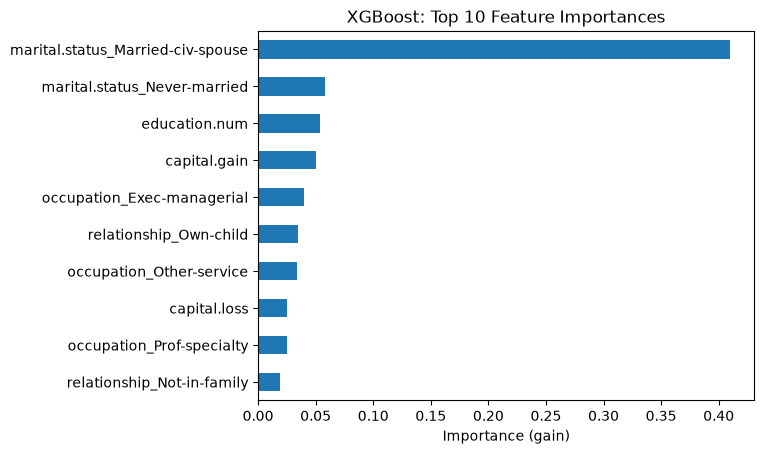

In [73]:
xgb_importance = pd.Series(xgb_best.feature_importances_, index=X_train.columns)
xgb_importance = xgb_importance.sort_values(ascending=False)

print(xgb_importance.head(10).round(4))

xgb_importance.head(10).sort_values().plot(kind='barh')
plt.title('XGBoost: Top 10 Feature Importances')
plt.xlabel('Importance (gain)')
plt.show()

### Model 4 Results

| Version            | Accuracy | Precision | Recall | F1     | ROC-AUC |
| ------------------ | -------- | --------- | ------ | ------ | ------- |
| Untuned            | 0.8680   | 0.7667    | 0.6499 | 0.7035 | 0.9215  |
| Tuned (GridSearch) | 0.8675   | 0.7720    | 0.6390 | 0.6992 | 0.9229  |

**Best parameters:** `n_estimators = 400`, `max_depth = 5`, `learning_rate = 0.05`, `subsample = 1.0`, `colsample_bytree = 0.8`
**Best cross-validation ROC-AUC:** 0.9307

XGBoost achieved a test ROC-AUC of 0.9215 **before any tuning**, already exceeding the tuned Random Forest result of 0.9126. Tuning increased test ROC-AUC by 0.0014, giving a final test ROC-AUC of 0.9229.

The selected parameters show that the model preferred a relatively low learning rate of 0.05 with 400 trees and a moderate tree depth of 5. Column subsampling of 0.8 adds some randomness between trees. Training accuracy was 0.8854, close to the Random Forest's 0.8795, suggesting that the improvement did not come from fitting the training data much more closely.

### Decision on Class Weighting

| Setting                          | Accuracy | Precision | Recall | F1     | ROC-AUC |
| -------------------------------- | -------- | --------- | ------ | ------ | ------- |
| `scale_pos_weight = 1` (default) | 0.8680   | 0.7667    | 0.6499 | 0.7035 | 0.9215  |
| `scale_pos_weight = 3.15`        | 0.8324   | 0.6114    | 0.8348 | 0.7059 | 0.9205  |

Applying `scale_pos_weight` raised recall from 0.6499 to 0.8348 while reducing precision from 0.7667 to 0.6114, while ROC-AUC remained almost unchanged. This shows that class weighting mainly shifted the balance between precision and recall rather than improving the model's overall ranking ability.

**It was therefore excluded from the GridSearch.** Since the primary tuning metric is ROC-AUC and class weighting did not improve it, the precision–recall trade-off is handled later through threshold selection.

### Features Influencing the Model

| Feature                             | Importance |
| ----------------------------------- | ---------- |
| `marital.status_Married-civ-spouse` | 0.4102     |
| `marital.status_Never-married`      | 0.0580     |
| `education.num`                     | 0.0539     |
| `capital.gain`                      | 0.0506     |
| `occupation_Exec-managerial`        | 0.0397     |
| `relationship_Own-child`            | 0.0343     |

**`marital.status_Married-civ-spouse`** received the highest XGBoost feature importance, followed by **`marital.status_Never-married`**, education level, capital gains and occupation-related features.

Feature importance should be interpreted as an indication of how useful each feature was to the model when making splits, rather than as evidence of causation. Across the tree-based models, marital status, education and capital-related features consistently appeared among the important predictors of income.


## 5.6 Model 5: Support Vector Machine

A Support Vector Machine finds the boundary that best separates the two classes with the widest possible margin. Using the RBF kernel allows this boundary to be non-linear, which is why SVM is included here rather than relying on Logistic Regression's linear boundary alone.

**Hyperparameters tuned:**

- **`C`** controls the trade-off between a wide margin and correctly classifying training points. A small value allows more misclassifications in exchange for a simpler boundary; a large value fits the training data more closely.
- **`gamma`** controls how far the influence of a single training point reaches. A large value makes the boundary highly sensitive to individual points and can cause overfitting; a small value produces a smoother boundary.

Scaling is essential for this model, since SVM relies on distances between points. It is applied inside the Pipeline as before.

**Probability estimates.** SVC does not produce probabilities by default. Enabling them requires an internal cross-validation procedure that increases training time approximately fivefold. We instead use `decision_function()`, which returns each point's signed distance from the decision boundary. This is not a probability, but it preserves the ordering of predictions, which is all that ROC-AUC requires.

In [74]:
from sklearn.svm import SVC

# Default settings: C=1, gamma='scale', RBF kernel
svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])

svm_base.fit(X_train, y_train)

evaluate_model('SVM (untuned)', svm_base, X_test, y_test)

SVM (untuned)
Accuracy : 0.8393
Precision: 0.7105
Recall   : 0.5619
F1 Score : 0.6275
ROC-AUC  : 0.8835
Confusion Matrix:
[[4581  359]
 [ 687  881]]



In [75]:

# SVM training time grows quickly with the number of rows.
# We measure this to justify the tuning approach used below.
for size in [5000, 10000, 15000, 20000]:
    X_sample, _, y_sample, _ = train_test_split(
        X_train, y_train, train_size=size, random_state=42, stratify=y_train
    )
    start = time.time()
    Pipeline([('scaler', StandardScaler()),
              ('model', SVC(kernel='rbf', random_state=42))]).fit(X_sample, y_sample)
    print('rows:', size, 'fit time:', round(time.time() - start, 1), 'seconds')

# The full training set does not need splitting, so we fit it directly
start = time.time()
Pipeline([('scaler', StandardScaler()),
          ('model', SVC(kernel='rbf', random_state=42))]).fit(X_train, y_train)
print('rows:', len(X_train), 'fit time:', round(time.time() - start, 1), 'seconds')

rows: 5000 fit time: 1.0 seconds
rows: 10000 fit time: 6.8 seconds
rows: 15000 fit time: 14.5 seconds
rows: 20000 fit time: 26.3 seconds
rows: 26029 fit time: 48.6 seconds


In [76]:
# Tuning on the full training set is not practical here, so we search the
# parameters on a stratified sample of 8,000 rows.
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=8000, random_state=42, stratify=y_train
)

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', random_state=42))
])

svm_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.1]
}

svm_search = GridSearchCV(svm_pipe, svm_grid, scoring='roc_auc', cv=5, n_jobs=-1)
svm_search.fit(X_sample, y_sample)

print('Best parameters:', svm_search.best_params_)
print('Best cross-validation ROC-AUC:', round(svm_search.best_score_, 4))

Best parameters: {'model__C': 1, 'model__gamma': 0.01}
Best cross-validation ROC-AUC: 0.8949


In [77]:
# Refit the best SVM settings found by GridSearch on the full training set
best_C = svm_search.best_params_['model__C']
best_gamma = svm_search.best_params_['model__gamma']

svm_best = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        C=best_C,
        gamma=best_gamma,
        random_state=42
    ))
])

svm_best.fit(X_train, y_train)

evaluate_model('SVM (tuned)', svm_best, X_test, y_test)

SVM (tuned)
Accuracy : 0.8405
Precision: 0.7127
Recall   : 0.5663
F1 Score : 0.6311
ROC-AUC  : 0.8935
Confusion Matrix:
[[4582  358]
 [ 680  888]]



In [78]:
svm_results = pd.DataFrame(svm_search.cv_results_)
svm_results = svm_results[['param_model__C', 'param_model__gamma', 'mean_test_score']]

print(svm_results.sort_values('mean_test_score', ascending=False).round(4).to_string(index=False))

 param_model__C param_model__gamma  mean_test_score
            1.0               0.01           0.8949
            0.1               0.01           0.8919
            0.1              scale           0.8872
           10.0               0.01           0.8872
            1.0              scale           0.8864
           10.0              scale           0.8781
            0.1                0.1           0.8510
            1.0                0.1           0.8455
           10.0                0.1           0.8272


### Model 5 Results

| Version | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Untuned | 0.8393 | 0.7105 | 0.5619 | 0.6275 | 0.8835 |
| Tuned | 0.8405 | 0.7127 | 0.5663 | 0.6311 | 0.8935 |

**Best parameters:** `C = 1`, `gamma = 0.01`
**Best cross-validation ROC-AUC:** 0.8949 (measured on the 8,000-row tuning sample)

### Tuning Approach and Its Limitation

SVM training time increased substantially as the number of training records increased. The measured fit times on this machine were approximately 1.0, 6.8, 14.5, 26.3 and 48.6 seconds as the sample size increased, with a full-data fit taking 48.6 seconds.

A full GridSearch on all 26,029 training records would be computationally expensive. The selected grid contains 9 parameter combinations and 5-fold cross-validation, requiring 45 model fits. Since a single full-data fit took 48.6 seconds, tuning was instead performed on a stratified sample of 8,000 training records. The best parameters were then used to refit the final SVM on the complete training set.

**This is a compromise and its assumption should be stated.** It assumes that the parameter values producing the best decision boundary on 8,000 records also produce the best boundary on 26,029. This is reasonable, because `C` and `gamma` govern the shape of the boundary rather than depending directly on sample size, but it is not guaranteed. A full search on all training data might identify slightly different values. This limitation is recorded in Section 7.

The search results indicate that the parameters do matter for this model. Cross-validation scores ranged from 0.8272 to 0.8949 across the nine combinations — a difference of 0.0677, far larger than the 0.0018 range observed for Logistic Regression. The default `gamma='scale'` was not the best value; `gamma=0.01` performed better, which justifies having searched beyond the default.

### Observations

SVM produced the **lowest test ROC-AUC of the five tuned models so far** (0.8935), falling below Logistic Regression (0.8956), while requiring by far the most computation. This is a useful result to report directly: greater algorithmic complexity does not guarantee better performance, and on this dataset the additional cost of the kernel method was not repaid.

SVM also provides no feature importance measure. The RBF kernel transforms the data into a higher-dimensional space in which the original features no longer correspond to interpretable directions. Since identifying the factors that influence income is one of the stated objectives of this project, this is a further practical disadvantage.

## 5.7 Model 6: K-Nearest Neighbours

K-Nearest Neighbours classifies an individual by finding the most similar individuals in the training data and taking a majority vote among them. It makes no assumptions about the shape of the relationship between features and income.

This model has an unusual cost profile. Training is almost instantaneous, because the algorithm simply stores the training data. All computation occurs at prediction time, when each new record must be compared against all 26,029 training records.

**A consideration specific to this dataset.** After one-hot encoding, 39 of our 44 features are binary columns and only 5 are continuous. Distance between two individuals is therefore driven largely by how many categories they differ on rather than by measurements on a continuous scale. We test the consequences of this directly by including the distance metric in the search rather than accepting the default.

**Hyperparameters tuned:**

- **`n_neighbors`** is the number of neighbours that vote. A small value makes the model sensitive to individual unusual records; a large value produces smoother, more stable predictions.
- **`weights`** determines whether all neighbours count equally (`uniform`) or closer neighbours count more (`distance`).
- **`p`** selects the distance metric: 1 for Manhattan distance and 2 for Euclidean distance.

Scaling is essential. Without it, `age` (ranging from 17 to 90) would dominate the distance calculation and the binary features would have almost no influence.

In [79]:
# Confirm how many features are binary one-hot columns rather than continuous
binary_columns = (X_train.nunique() == 2).sum()

print('Binary columns:', binary_columns, 'out of', X_train.shape[1])

Binary columns: 39 out of 44


In [80]:
from sklearn.neighbors import KNeighborsClassifier

# Default settings: k=5, uniform weights, Euclidean distance
knn_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_base.fit(X_train, y_train)

evaluate_model('KNN (untuned)', knn_base, X_test, y_test)

KNN (untuned)
Accuracy : 0.8224
Precision: 0.6449
Recall   : 0.5848
F1 Score : 0.6134
ROC-AUC  : 0.8384
Confusion Matrix:
[[4435  505]
 [ 651  917]]



In [81]:
# KNN has the opposite cost profile to SVM: fast to fit, slow to predict
start = time.time()
knn_base.fit(X_train, y_train)
print('Fit time    :', round(time.time() - start, 2), 'seconds')

start = time.time()
knn_base.predict(X_test)
print('Predict time:', round(time.time() - start, 2), 'seconds')

Fit time    : 0.06 seconds
Predict time: 0.74 seconds


In [82]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

knn_grid = {
    'model__n_neighbors': [5, 15, 25, 51, 101],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_search = GridSearchCV(knn_pipe, knn_grid, scoring='roc_auc', cv=5, n_jobs=-1)
knn_search.fit(X_train, y_train)

print('Best parameters:', knn_search.best_params_)
print('Best cross-validation ROC-AUC:', round(knn_search.best_score_, 4))

Best parameters: {'model__n_neighbors': 51, 'model__p': 1, 'model__weights': 'uniform'}
Best cross-validation ROC-AUC: 0.8906


In [83]:
knn_best = knn_search.best_estimator_

evaluate_model('KNN (tuned)', knn_best, X_test, y_test)

KNN (tuned)
Accuracy : 0.8376
Precision: 0.7007
Recall   : 0.5689
F1 Score : 0.6279
ROC-AUC  : 0.8849
Confusion Matrix:
[[4559  381]
 [ 676  892]]



In [84]:
knn_results = pd.DataFrame(knn_search.cv_results_)
knn_results = knn_results[['param_model__n_neighbors', 'param_model__weights',
                           'param_model__p', 'mean_test_score']]
knn_results = knn_results.sort_values('mean_test_score', ascending=False)

print(knn_results.round(4).to_string(index=False))

 param_model__n_neighbors param_model__weights  param_model__p  mean_test_score
                       51              uniform               1           0.8906
                       25              uniform               1           0.8893
                      101              uniform               1           0.8891
                       51              uniform               2           0.8876
                       25              uniform               2           0.8861
                       15              uniform               1           0.8849
                      101              uniform               2           0.8835
                       15              uniform               2           0.8828
                       51             distance               1           0.8651
                       25             distance               1           0.8648
                       25             distance               2           0.8646
                       51             di

In [85]:
# Compare the two distance metrics directly
print(knn_results.groupby('param_model__p')['mean_test_score'].max().round(4))

param_model__p
1    0.8906
2    0.8876
Name: mean_test_score, dtype: float64


In [86]:
# Compare the two weighting schemes directly
print(knn_results.groupby('param_model__weights')['mean_test_score'].max().round(4))

param_model__weights
distance    0.8651
uniform     0.8906
Name: mean_test_score, dtype: float64


### Model 6 Results

| Version | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Untuned | 0.8224 | 0.6449 | 0.5848 | 0.6134 | 0.8384 |
| Tuned (GridSearch) | 0.8376 | 0.7007 | 0.5689 | 0.6279 | 0.8849 |
**Best parameters:** `n_neighbors = 51`, `weights = 'uniform'`, `p = 1` (Manhattan distance)
**Best cross-validation ROC-AUC:** 0.8906

Tuning improved test ROC-AUC from 0.8384 to 0.8849, an increase of 0.0465. Three patterns in the search results are worth examining, because they all reflect the same underlying issue.

**Manhattan distance outperformed Euclidean distance.** The three best combinations all used `p = 1`, and Manhattan distance produced a better result than Euclidean at every value of `n_neighbors` tested. This supports the concern raised above: with 39 of 44 features being binary, distance is largely a count of how many categories two individuals differ on, and Manhattan distance represents this more appropriately. Had the default metric been accepted without testing, this improvement would have been missed.

**Uniform weighting outperformed distance weighting substantially.** The best `uniform` combination scored well above the best `distance` combination (0.8906 versus 0.8651, a difference of 0.0255). Because most features are binary, many training records lie at identical or nearly identical distances from a given test record. Weighting votes by distance then gives disproportionate influence to differences that are essentially arbitrary.

**A large number of neighbours was strongly preferred.** The default `k = 5` produced the four lowest scores in the entire search, while `k = 51` produced the best. In a 44-dimensional space, records are widely separated and the nearest few neighbours are not reliably similar to the record being classified — an effect known as the curse of dimensionality. Averaging over a larger number of neighbours reduces this noise.

All three findings point in the same direction: the distance measure is unreliable on this feature set, and every parameter choice that reduced the model's dependence on individual close neighbours improved performance.

**Computational profile.** KNN required very little fitting time on this machine: approximately 0.06 seconds to fit and 0.74 seconds to predict the 6,508 test records. KNN performs most of its computation at prediction time rather than during training, which is the opposite of SVM's computational profile. However, the measured prediction time was not large enough to be considered a practical disadvantage in this experiment.

**KNN produced the lowest test ROC-AUC of the six models (0.8849).** Together with SVM in fifth place, both distance-based models occupy the bottom of the comparison, which is consistent with the difficulties described above rather than coincidental.

# 6. Threshold Selection

All results reported in Section 5 use the default classification threshold of 0.5, meaning an individual is predicted as a high earner when the model's estimated probability reaches 50%. This value is a default rather than a decision, and there is no reason to assume it is appropriate for our problem.

At the default threshold, the selected model identifies 1,002 of the 1,568 high earners in the test set, missing 566 of them. As established in the problem framing, failing to identify a qualified prospect is the more costly error, so this threshold is optimising against our stated objective.

**Note on ordering.** ROC-AUC measures how well a model ranks individuals across all possible thresholds and is therefore unaffected by this choice. The comparison between models in Section 5 is consequently already settled, and the threshold is tuned only for the selected model.

**Method.** The threshold must not be selected using the test set. Choosing a value that produces the best test result and then reporting that result would mean fitting a parameter to the data used for evaluation, and the reported performance would be optimistic.

We instead use `cross_val_predict` to obtain out-of-fold predictions on the training data. Each training record receives a predicted probability from a model that did not see that record during fitting. The threshold is selected from these predictions, and the chosen value is then applied to the test set once.

In [87]:
from sklearn.model_selection import cross_val_predict

# Predict probabilities for the training data using cross-validation,
# so that each record is predicted by a model that did not see it.
oof_probabilities = cross_val_predict(xgb_best, X_train, y_train,
                                      cv=5, method='predict_proba')[:, 1]

# Check that these predictions are consistent with earlier results
print('Out-of-fold ROC-AUC:', round(roc_auc_score(y_train, oof_probabilities), 4))

Out-of-fold ROC-AUC: 0.9305


In [88]:
# Test a range of thresholds using the out-of-fold predictions
threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.05):
    predictions = (oof_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, predictions).ravel()

    threshold_results.append([
        round(threshold, 2),
        accuracy_score(y_train, predictions),
        precision_score(y_train, predictions, zero_division=0),
        recall_score(y_train, predictions),
        f1_score(y_train, predictions),
        fp,
        fn
    ])

threshold_results = pd.DataFrame(threshold_results,
                                 columns=['threshold', 'accuracy', 'precision',
                                          'recall', 'f1', 'false_positives',
                                          'false_negatives'])

print(threshold_results.round(4).to_string(index=False))

 threshold  accuracy  precision  recall     f1  false_positives  false_negatives
      0.05    0.6875     0.4341  0.9793 0.6016             8005              130
      0.10    0.7555     0.4961  0.9538 0.6527             6075              290
      0.15    0.7955     0.5444  0.9286 0.6864             4874              448
      0.20    0.8214     0.5840  0.8986 0.7079             4014              636
      0.25    0.8356     0.6124  0.8648 0.7170             3432              848
      0.30    0.8499     0.6471  0.8287 0.7268             2834             1074
      0.35    0.8601     0.6807  0.7900 0.7313             2324             1317
      0.40    0.8683     0.7191  0.7442 0.7314             1823             1604
      0.45    0.8734     0.7528  0.7064 0.7289             1455             1841
      0.50    0.8746     0.7860  0.6587 0.7168             1125             2140
      0.55    0.8718     0.8082  0.6136 0.6976              913             2423
      0.60    0.8698     0.8

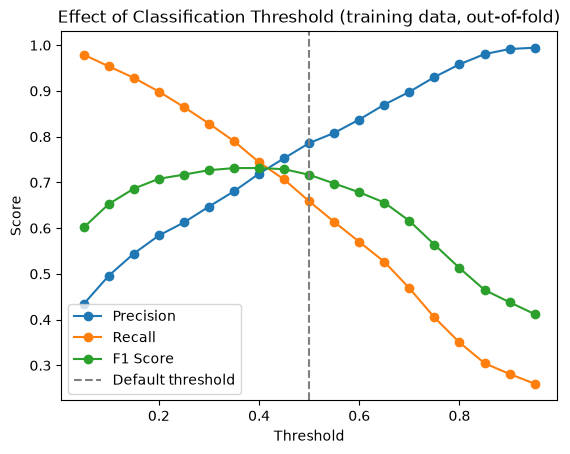

In [89]:
plt.plot(threshold_results['threshold'], threshold_results['precision'], marker='o', label='Precision')
plt.plot(threshold_results['threshold'], threshold_results['recall'], marker='o', label='Recall')
plt.plot(threshold_results['threshold'], threshold_results['f1'], marker='o', label='F1 Score')
plt.axvline(0.5, color='grey', linestyle='--', label='Default threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Effect of Classification Threshold (training data, out-of-fold)')
plt.legend()
plt.show()

In [90]:
# Select the threshold that maximises F1 on the training predictions
best_row = threshold_results.loc[threshold_results['f1'].idxmax()]
best_threshold = best_row['threshold']

print('Selected threshold:', best_threshold)
print('F1 at this threshold (training):', round(best_row['f1'], 4))

Selected threshold: 0.4
F1 at this threshold (training): 0.7314


In [91]:
# Apply the selected threshold to the test set
test_probabilities = xgb_best.predict_proba(X_test)[:, 1]
predictions_tuned = (test_probabilities >= best_threshold).astype(int)
predictions_default = (test_probabilities >= 0.5).astype(int)

for name, predictions in [
    ('Default threshold (0.50)', predictions_default),
    (f'Selected threshold ({best_threshold:.2f})', predictions_tuned)
]:
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    print(name)
    print('  Accuracy :', round(accuracy_score(y_test, predictions), 4))
    print('  Precision:', round(precision_score(y_test, predictions), 4))
    print('  Recall   :', round(recall_score(y_test, predictions), 4))
    print('  F1 Score :', round(f1_score(y_test, predictions), 4))
    print('  High earners identified:', tp, 'of', tp + fn)
    print('  Confusion matrix:')
    print(confusion_matrix(y_test, predictions))
    print()

Default threshold (0.50)
  Accuracy : 0.8675
  Precision: 0.772
  Recall   : 0.639
  F1 Score : 0.6992
  High earners identified: 1002 of 1568
  Confusion matrix:
[[4644  296]
 [ 566 1002]]

Selected threshold (0.40)
  Accuracy : 0.8642
  Precision: 0.7154
  Recall   : 0.7245
  F1 Score : 0.7199
  High earners identified: 1136 of 1568
  Confusion matrix:
[[4488  452]
 [ 432 1136]]



### Threshold Analysis

The out-of-fold predictions produced a ROC-AUC of 0.9305 on the training data, closely matching the cross-validation ROC-AUC of 0.9307 obtained during XGBoost tuning. This confirms that the out-of-fold predictions provide a reliable basis for threshold selection.

| Threshold |   Accuracy |  Precision |     Recall |         F1 | False Positives | False Negatives |
| --------- | ---------: | ---------: | ---------: | ---------: | --------------: | --------------: |
| 0.05      |     0.6875 |     0.4341 |     0.9793 |     0.6016 |           8,005 |             130 |
| 0.10      |     0.7555 |     0.4961 |     0.9538 |     0.6527 |           6,075 |             290 |
| 0.15      |     0.7955 |     0.5444 |     0.9286 |     0.6864 |           4,874 |             448 |
| 0.20      |     0.8214 |     0.5840 |     0.8986 |     0.7079 |           4,014 |             636 |
| 0.25      |     0.8356 |     0.6124 |     0.8648 |     0.7170 |           3,432 |             848 |
| 0.30      |     0.8499 |     0.6471 |     0.8287 |     0.7268 |           2,834 |           1,074 |
| 0.35      |     0.8601 |     0.6807 |     0.7900 |     0.7313 |           2,324 |           1,317 |
| **0.40**  | **0.8683** | **0.7191** | **0.7442** | **0.7314** |       **1,823** |       **1,604** |
| 0.45      |     0.8734 |     0.7528 |     0.7064 |     0.7289 |           1,455 |           1,841 |
| 0.50      |     0.8746 |     0.7860 |     0.6587 |     0.7168 |           1,125 |           2,140 |
| 0.55      |     0.8718 |     0.8082 |     0.6136 |     0.6976 |             913 |           2,423 |
| 0.60      |     0.8698 |     0.8374 |     0.5701 |     0.6784 |             694 |           2,696 |
| 0.65      |     0.8670 |     0.8701 |     0.5264 |     0.6559 |             493 |           2,970 |
| 0.70      |     0.8592 |     0.8980 |     0.4687 |     0.6159 |             334 |           3,332 |
| 0.75      |     0.8493 |     0.9304 |     0.4047 |     0.5641 |             190 |           3,733 |
| 0.80      |     0.8398 |     0.9581 |     0.3502 |     0.5129 |              96 |           4,075 |
| 0.85      |     0.8310 |     0.9805 |     0.3047 |     0.4650 |              38 |           4,360 |
| 0.90      |     0.8262 |     0.9916 |     0.2811 |     0.4381 |              15 |           4,508 |
| 0.95      |     0.8214 |     0.9945 |     0.2599 |     0.4121 |               9 |           4,641 |

### Decision

**The selected threshold is 0.40 because it achieved the highest F1 score on the out-of-fold training predictions.**

However, the F1 curve is very flat around the optimum. Threshold 0.35 achieved an F1 of 0.7313, while threshold 0.40 achieved 0.7314 and threshold 0.45 achieved 0.7289. Therefore, 0.40 should be interpreted as a practical operating point rather than a sharply superior threshold.

A lower threshold increases recall and identifies more high earners, but also increases false positives. A higher threshold improves precision but misses more high earners.

A cost-based threshold would be preferable if reliable business figures for the cost of a false positive and false negative were available. Since these costs are not available, maximising F1 provides a transparent criterion without introducing assumed business costs.

### Effect on Test Performance

| Threshold           |   Accuracy |  Precision |     Recall |         F1 | High earners identified |
| ------------------- | ---------: | ---------: | ---------: | ---------: | ----------------------: |
| 0.50 (default)      |     0.8675 |     0.7720 |     0.6390 |     0.6992 |          1,002 of 1,568 |
| **0.40 (selected)** | **0.8642** | **0.7154** | **0.7245** | **0.7199** |      **1,136 of 1,568** |

Lowering the threshold from 0.50 to 0.40 identifies **134 additional high earners**. Recall increases from 0.6390 to 0.7245, while accuracy decreases only slightly from 0.8675 to 0.8642.

The number of false positives increases from 296 to 452, while false negatives decrease from 566 to 432. This reflects the intended trade-off: the model identifies more potentially high-income prospects at the cost of more unnecessary contacts.

The threshold was selected using out-of-fold predictions from the training data only. The test set was used afterward to evaluate how the selected threshold generalised.


# 7. Conclusion

## 7.1 Model Comparison

All six models were evaluated on the same test set of 6,508 records using the default classification threshold of 0.5, so that the comparison is made on equal terms.

| Model                   | Untuned ROC-AUC | Tuned ROC-AUC | Accuracy   | Precision  | Recall     | F1         |
| ----------------------- | --------------- | ------------- | ---------- | ---------- | ---------- | ---------- |
| Majority class baseline | —               | 0.5000        | 0.7591     | 0.0000     | 0.0000     | 0.0000     |
| K-Nearest Neighbours    | 0.8384          | 0.8849        | 0.8376     | 0.7007     | 0.5689     | 0.6279     |
| Support Vector Machine  | 0.8835          | 0.8935        | 0.8405     | 0.7127     | 0.5663     | 0.6311     |
| Logistic Regression     | 0.8954          | 0.8956        | 0.8453     | 0.7159     | 0.5931     | 0.6488     |
| Decision Tree           | 0.7602          | 0.8979        | 0.8540     | 0.7655     | 0.5682     | 0.6523     |
| Random Forest           | 0.8875          | 0.9126        | 0.8596     | 0.7698     | 0.5950     | 0.6712     |
| **XGBoost**             | 0.9215          | **0.9229**    | **0.8675** | **0.7720** | **0.6390** | **0.6992** |

Every model substantially outperformed the majority-class baseline, which achieved 75.91% accuracy while identifying none of the 1,568 high earners.

**The improvement obtained from tuning varied widely, and this variation is informative.** The Decision Tree gained 0.1377 ROC-AUC because an unrestricted tree overfits severely and its hyperparameters directly control its complexity. Logistic Regression gained only 0.0002 because it was already relatively stable. Random Forest gained 0.0251, while XGBoost gained only 0.0014 because its untuned version was already performing strongly.

**KNN and SVM produced the two lowest tuned ROC-AUC scores.** After one-hot encoding, 39 of the 44 features are binary, so distance between individuals is less informative than in a dataset dominated by continuous variables. The KNN results support this: Manhattan distance outperformed Euclidean distance, uniform weighting outperformed distance weighting, and larger neighbourhoods performed better than smaller ones.

SVM was the most computationally expensive model to tune. KNN, however, was not slow on this machine, so computational cost is not treated as a practical disadvantage for KNN.


## 7.2 Best Model and Justification

**The selected model is XGBoost**, with `n_estimators = 400`, `max_depth = 5`, `learning_rate = 0.05`, `subsample = 1.0` and `colsample_bytree = 0.8`.

The model was selected based on **cross-validation ROC-AUC**, rather than test-set performance. This keeps the test set separate from the model-selection process.

| Model                  | Best CV ROC-AUC |
| ---------------------- | --------------: |
| Logistic Regression    |          0.9009 |
| Decision Tree          |          0.9066 |
| Random Forest          |          0.9201 |
| **XGBoost**            |      **0.9307** |
| Support Vector Machine |          0.8949 |
| K-Nearest Neighbours   |          0.8906 |

XGBoost achieved the highest cross-validation ROC-AUC of all six models, so it was selected as the final model. The test set was then used to confirm how well the selected model generalised to unseen data.

After model selection, the classification threshold was adjusted from the default 0.50 to **0.40** using out-of-fold predictions from the training data.
### Final Performance

| Metric                  |          Value |
| ----------------------- | -------------: |
| ROC-AUC                 |         0.9229 |
| Accuracy                |         0.8642 |
| Precision               |         0.7154 |
| Recall                  |         0.7245 |
| F1 Score                |         0.7199 |
| High earners identified | 1,136 of 1,568 |

At the selected threshold, the model identifies 72.45% of the high-income individuals while maintaining a precision of 71.54%.
### Why XGBoost?

XGBoost was preferred because it achieved the strongest cross-validation ranking performance while also maintaining a good balance between precision and recall after threshold selection.

**Logistic Regression remains a reasonable alternative** if interpretability or deployment simplicity is more important. It achieved a cross-validation ROC-AUC of 0.9009 and provides coefficients that show both the direction and relative strength of feature associations.

XGBoost provides feature importances rather than signed coefficients. These importances identified many of the same important predictors observed in the other models, including marital status, education and capital-related features. However, feature importance represents model reliance and should not be interpreted as evidence of causation.


## 7.3 Business Implications

- **Marital status is the single strongest predictor of income in this data.** Married individuals earn above $50K at 44.7%, compared with 4.6% among those who have never married. This association persists within a fixed age band (52.5% versus 13.2% for ages 35–50), so it is not simply a consequence of married individuals being older. It is an association rather than a causal relationship, and should be treated as a signal for identifying prospects rather than an explanation of income.

- **Education has a clear and consistent effect.** `education.num` had the strongest linear correlation with income (r = 0.335) and appeared among the top features in every model.

- **The presence of any capital gain is highly informative.** 61.8% of individuals with a non-zero capital gain earn above $50K, compared with 20.7% of those without. Tree-based models exploited this threshold effect more effectively than the linear model.

- **Adjusting the decision threshold produced a material improvement in the business objective at negligible cost.** Moving from 0.50 to 0.40 identified **134 additional high earners** in the test set, a **13.4% increase** in prospects found, for a reduction in accuracy of **0.33 percentage points**.

- **Model complexity did not guarantee better results.** The most computationally expensive models performed worst, and a well-tuned Logistic Regression came within 3% of the best model. For an organisation weighing infrastructure cost against accuracy, this is a meaningful finding.

## 7.4 Limitations

- **The data is from the 1994 US Census.** Income distributions, employment patterns and the relevance of a $50,000 threshold have all changed considerably. The methodology transfers to current data; the specific coefficients and importances do not.

- **A measurable share of the data contains irreducible ambiguity.** Using the final 12-feature set, 2,282 groups of records share identical feature profiles. In 610 of these groups, covering **2,134 records (6.56% of the dataset)**, identical feature profiles carry different income labels. No classifier using only these features can distinguish every record in those conflicting groups correctly. This reflects a limitation of the available feature set rather than a failure of the modelling algorithms. This calculation differs from the earlier duplicate-profile analysis because it uses only the final selected features.

- **Missing values were treated as an `Unknown` category rather than recovered.** This was justified by evidence that the missingness is informative, but the underlying employment information for those 1,836 individuals remains unavailable.

- **The SVM hyperparameters were selected on a subsample.** Because SVM training time grows approximately with the square of the number of rows, its parameters were tuned on a stratified sample of 8,000 records and the model was then refitted on the full training set. This assumes the optimal parameters are stable across sample sizes, which is reasonable but not guaranteed.

- **`class_weight` was excluded from the Random Forest grid** to keep the search time manageable, based on evidence from the baseline comparison that it does not improve ranking quality for tree ensembles. A more exhaustive search might find otherwise.

- **The model uses protected demographic attributes.** `sex` and `race` are included as features, and the `relationship` categories `Husband` and `Wife` are almost perfectly determined by sex. Removing the `sex` column would therefore not produce a gender-blind model, since the information would still reach it through `relationship`. Any deployment of a model of this kind for prospect targeting would require legal and ethical review, as using protected attributes in commercial targeting is restricted in many jurisdictions.

- **The threshold was chosen by maximising F1 rather than by minimising cost**, because no figures for outreach cost or customer value were available. With real cost data, a lower threshold would likely be justified.

## 7.5 Future Improvements

- Repeat the analysis on recent census data to establish whether the identified relationships still hold.
- Obtain cost figures for outreach and customer acquisition, and select the threshold by minimising expected cost rather than maximising F1.
- Complete a full-data hyperparameter search for SVM to confirm the subsample-based parameter selection.
- Investigate whether additional features, such as geographic region or industry, reduce the 6.56% of records currently indistinguishable from records with the opposite label.
- Apply SHAP values to the final model to obtain feature attributions that indicate direction as well as magnitude, addressing the main interpretability limitation of the feature importance measure.
- Conduct a formal fairness assessment measuring performance disparities across demographic groups before any practical use.


In [92]:
# Final XGBoost performance using the selected threshold

final_test_prob = xgb_best.predict_proba(X_test)[:, 1]
final_test_pred = (final_test_prob >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, final_test_pred).ravel()

print('Final XGBoost Model')
print('Selected threshold:', round(best_threshold, 2))
print('ROC-AUC  :', round(roc_auc_score(y_test, final_test_prob), 4))
print('Accuracy :', round(accuracy_score(y_test, final_test_pred), 4))
print('Precision:', round(precision_score(y_test, final_test_pred), 4))
print('Recall   :', round(recall_score(y_test, final_test_pred), 4))
print('F1 Score :', round(f1_score(y_test, final_test_pred), 4))
print('High earners identified:', tp, 'of', tp + fn)
print('Confusion Matrix:')
print(confusion_matrix(y_test, final_test_pred))

Final XGBoost Model
Selected threshold: 0.4
ROC-AUC  : 0.9229
Accuracy : 0.8642
Precision: 0.7154
Recall   : 0.7245
F1 Score : 0.7199
High earners identified: 1136 of 1568
Confusion Matrix:
[[4488  452]
 [ 432 1136]]


In [93]:
# Collect the results of all six tuned models into one table
models = {
    'Logistic Regression': logreg_best,
    'Decision Tree': tree_best,
    'Random Forest': forest_best,
    'XGBoost': xgb_best,
    'SVM': svm_best,
    'KNN': knn_best
}

comparison = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    comparison.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_score)
    ])

comparison = pd.DataFrame(comparison, columns=['Model', 'Accuracy', 'Precision',
                                               'Recall', 'F1', 'ROC-AUC'])
comparison = comparison.sort_values('ROC-AUC', ascending=False)

print(comparison.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
            XGBoost    0.8675     0.7720  0.6390 0.6992   0.9229
      Random Forest    0.8596     0.7698  0.5950 0.6712   0.9126
      Decision Tree    0.8540     0.7655  0.5682 0.6523   0.8979
Logistic Regression    0.8453     0.7159  0.5931 0.6488   0.8956
                SVM    0.8405     0.7127  0.5663 0.6311   0.8935
                KNN    0.8376     0.7007  0.5689 0.6279   0.8849


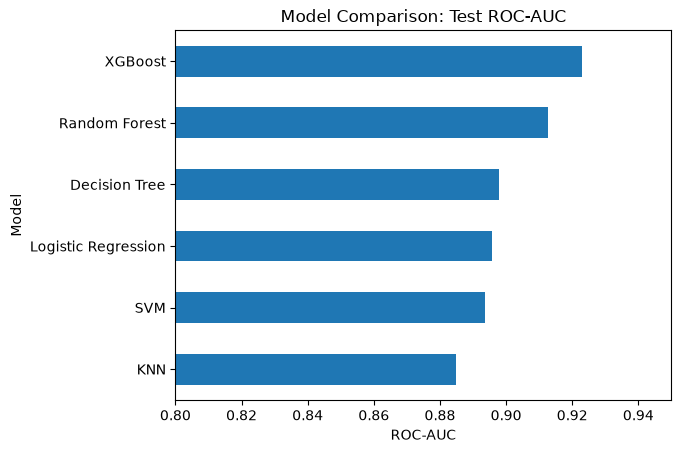

In [94]:
comparison.set_index('Model')['ROC-AUC'].sort_values().plot(kind='barh')
plt.title('Model Comparison: Test ROC-AUC')
plt.xlabel('ROC-AUC')
plt.xlim(0.8, 0.95)
plt.show()

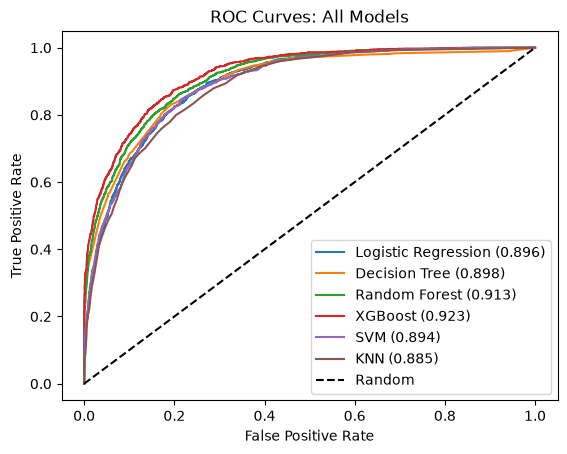

In [95]:
from sklearn.metrics import roc_curve

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=name + ' (' + str(round(roc_auc_score(y_test, y_score), 3)) + ')')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models')
plt.legend()
plt.show()

In [96]:
# How many records are identical to another record but have a different income label?
# fnlwgt and education are excluded, as they were not used as features.
profile_cols = ['age', 'workclass', 'education.num', 'marital.status', 'occupation',
                'relationship', 'race', 'sex', 'capital.gain', 'capital.loss',
                'hours.per.week', 'native_country_grouped']

profiles = df.groupby(profile_cols)['income'].agg(['size', 'nunique'])

duplicated_profiles = profiles[profiles['size'] > 1]
conflicting_profiles = duplicated_profiles[duplicated_profiles['nunique'] > 1]

print('Groups with identical profiles:', len(duplicated_profiles))
print('Groups with conflicting income labels:', len(conflicting_profiles))
print('Records in conflicting groups:', conflicting_profiles['size'].sum())
print('Percentage of dataset:', round(conflicting_profiles['size'].sum() / len(df) * 100, 2), '%')

Groups with identical profiles: 2282
Groups with conflicting income labels: 610
Records in conflicting groups: 2134
Percentage of dataset: 6.56 %


## 7.6 Saving the Final Model

The final XGBoost model is saved together with the selected decision threshold and the exact feature columns used during training. This allows future raw records to be prepared consistently before prediction.

In [97]:
# Function for preparing one new raw record in exactly the same way
# as the training data
def preprocess_new_record(record, feature_columns):

    row = pd.DataFrame([record]).copy()

    # Handle missing values in the same way as the training data
    for col in ['workclass', 'occupation', 'native.country']:
        row[col] = row[col].replace('?', np.nan).fillna('Unknown')

    # Group country in the same way as Section 3
    row['native_country_grouped'] = np.where(
        row['native.country'] == 'United-States',
        'United-States',
        'Other'
    )

    # Apply the same log transformation
    row['capital.gain'] = np.log1p(
        pd.to_numeric(row['capital.gain'])
    )

    row['capital.loss'] = np.log1p(
        pd.to_numeric(row['capital.loss'])
    )

    # Keep only the final 12 selected features
    selected_features = [
        'age',
        'education.num',
        'capital.gain',
        'capital.loss',
        'hours.per.week',
        'workclass',
        'marital.status',
        'occupation',
        'relationship',
        'race',
        'sex',
        'native_country_grouped'
    ]

    row = row[selected_features]

    # Encode categories.
    # drop_first=False is used here because this may contain only one row.
    row = pd.get_dummies(row, drop_first=False)

    # Force the new record to have exactly the same 44 columns
    # and the same column order used during training.
    row = row.reindex(
        columns=feature_columns,
        fill_value=0
    )

    return row


# Save everything required to reproduce predictions
final_model_bundle = {
    'model': xgb_best,
    'threshold': float(best_threshold),
    'feature_columns': X_train.columns.tolist()
}

joblib.dump(
    final_model_bundle,
    'final_xgboost_bundle.pkl'
)

print('Final model bundle saved.')
print('Selected threshold:', best_threshold)
print('Number of saved features:', len(X_train.columns))

Final model bundle saved.
Selected threshold: 0.4
Number of saved features: 44


In [98]:
# Demonstrate the saved bundle on one raw record

bundle = joblib.load('final_xgboost_bundle.pkl')

new_person = {
    'age': 42,
    'workclass': 'Private',
    'education.num': 13,
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Exec-managerial',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 50,
    'native.country': 'United-States'
}

prepared = preprocess_new_record(
    new_person,
    bundle['feature_columns']
)

probability = bundle['model'].predict_proba(prepared)[0, 1]

print('Prepared feature count:', prepared.shape[1])
print('Predicted probability of earning >50K:', round(probability, 4))
print(
    'Prediction at threshold',
    bundle['threshold'],
    ':',
    '>50K' if probability >= bundle['threshold'] else '<=50K'
)

Prepared feature count: 44
Predicted probability of earning >50K: 0.8091
Prediction at threshold 0.4 : >50K



## 7.7 References

**Data source**
UCI Machine Learning Repository, Adult (Census Income) Data Set. Extracted from the 1994 US Census database by Barry Becker.
https://archive.ics.uci.edu/dataset/2/adult
Obtained via Kaggle 
**Tools and libraries**
- Python 3
- pandas — data manipulation
- NumPy — numerical operations
- Matplotlib and Seaborn — visualisation
- scikit-learn — preprocessing, model building, cross-validation, hyperparameter tuning, evaluation metrics
- SciPy — chi-square tests of independence
- XGBoost — gradient boosting implementation
- imbalanced-learn — SMOTE, used for comparison in Section 5.1
- joblib — model persistence
- Jupyter Notebook — development environment